# MK9: Empirical Covariance Adaptive + Newton Distance Snap

## Key insight
The 8x8 Fisher conditional Hessian gives eigenmode proposal widths that are
**100-15000x too small** for the bottleneck CW params (cos_gwtheta, gwphi, cos_inc).
This is because the Hessian measures sensitivity at fixed distances, but the actual
posterior is much wider because distances can mode-hop to compensate for CW changes.

## Solution: Adaptive Metropolis with Empirical Covariance
1. **Phase 1 (burn-in first half)**: Use Fisher eigenmodes + Newton snap with aggressive
   adaptation to explore the posterior and build up chain samples
2. **Phase 2 (burn-in second half + production)**: Switch to eigenmodes of the 
   **empirical chain covariance**, which captures the actual posterior geometry
   including the effect of distance mode-hopping

Combined with Newton distance snapping (3 gradient evals per proposal) to keep
distances locked to peaks as CW params change.

**Result**: CW ESS improved from ~16 (MK5) to ~65 (**4x improvement**) with 13/13 coverage.

| Move | Probability | Description |
|------|------------|-------------|
| **CW Eigen + Dist Newton** | 35% | Empirical eigenmode step + Newton-snap all distances |
| **Distance within-mode** | 10% | Small 1D refinement using Fisher width |
| **Prior-snap big jump** | 30% | Draw from EM prior, snap to nearest peak |
| **Coherent freq-dist** | 10% | Joint frequency + scale distances + Newton |
| **CW Joint** | 15% | Full 8D empirical covariance proposal |

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["JAX_DISABLE_MMAP_CACHE"] = "1"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=2"

import glob, time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
jax.clear_caches()
import jax.numpy as jnp

import discovery as ds
from enterprise_extensions import load_feathers
from discovery.deterministic import make_phase_connected_binary
from discovery import const as disco_const
from discovery.deterministic import fpcmu_fast

print('Imports OK')

/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


Imports OK


In [2]:
# Load pulsars and their EM distance priors
feather_dir = "../data_products/"
Npulsars = 5

disco_psrs = [ds.Pulsar.read_feather(f) for f in sorted(glob.glob(feather_dir + "*.feather"))][:Npulsars]
for psr in disco_psrs:
    psr.toaerrs = np.full_like(psr.toas, 1e-6, dtype=np.float32)
print(f"Loaded {len(disco_psrs)} pulsars: {[p.name for p in disco_psrs]}")

psrs_ent = load_feathers.load_feathers_from_folder(feather_dir)
ent_by_name = {p.name: p for p in psrs_ent}

dist_mu = []
dist_sig = []
for psr in disco_psrs:
    ep = ent_by_name[psr.name]
    mu = float(ep.pdist[0])
    sig = float(ep.pdist[1]) if len(ep.pdist) > 1 else 0.5
    if (not np.isfinite(sig)) or sig <= 0:
        sig = 0.5
    dist_mu.append(mu)
    dist_sig.append(sig)

dist_mu = jnp.array(dist_mu, dtype=jnp.float64)
dist_sig = jnp.array(dist_sig, dtype=jnp.float64)

psr_toas_list = [np.asarray(psr.toas, dtype=np.float64) for psr in disco_psrs]
psr_pos_list = [psr.pos for psr in disco_psrs]
psr_positions = jnp.array([psr.pos for psr in disco_psrs])

sigma_toa = 1e-6
KPC_OVER_C = disco_const.kpc / disco_const.c

pnames_13 = (['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
              'log10_h', 'phase0', 'psi'] +
             [psr.name + '_dist' for psr in disco_psrs])

print(f"dist_mu: {[f'{float(d):.3f}' for d in dist_mu]}")
print(f"dist_sig: {[f'{float(d):.4f}' for d in dist_sig]}")

Loaded 5 pulsars: ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451']
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdi

FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1738+0333.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1738+0333.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1741+1351.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1741+1351.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1744-1134.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1744-1134.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1745+1017.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1745+1017.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ../data_products/J1747-4036.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data_products/J1747-4036.feather.
FeatherPulsar.r

dist_mu: ['1.180', '3.100', '4.640', '1.020', '0.330']
dist_sig: ['0.1200', '0.2000', '0.9300', '0.1100', '0.0036']


In [3]:
# CW injection and log-posterior definition
INJ = {
    "cos_gwtheta": 0.3, "gwphi": 2.5, "cos_inc": -0.2,
    "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
    "phase0": 1.0, "psi": 0.7,
}

cw_func = make_phase_connected_binary(pulsarterm=True)

@jax.jit
def compute_delta_L(cos_gwtheta, gwphi, log10_fgw):
    """Mode spacing in distance (kpc) for each pulsar."""
    gwtheta = jnp.arccos(cos_gwtheta)
    f_gw = 10.0 ** log10_fgw
    _, _, cos_mu = jax.vmap(
        lambda pos: fpcmu_fast(pos, gwtheta, gwphi)
    )(psr_positions)
    denom = jnp.abs(1.0 - cos_mu)
    denom = jnp.maximum(denom, 1e-4)
    return 1.0 / (f_gw * KPC_OVER_C * denom)

# Inject with distances offset from prior mean by 0.3 sigma
DIST_OFFSET_SIGMA = 0.3
p5_true_dists = {}
for i, psr in enumerate(disco_psrs):
    p5_true_dists[psr.name] = float(dist_mu[i]) + DIST_OFFSET_SIGMA * float(dist_sig[i])

p5_data_list = []
for i, psr in enumerate(disco_psrs):
    toas_i = np.asarray(psr.toas, dtype=np.float64)
    delay_i = cw_func(toas_i, psr.pos, p_dist=p5_true_dists[psr.name], **INJ)
    p5_data_list.append(np.array(delay_i, dtype=np.float64))

INJ_vals = [INJ[k] for k in ['cos_gwtheta','gwphi','cos_inc','log10_mc','log10_fgw','log10_h','phase0','psi']]
p5_dist_vals = [p5_true_dists[psr.name] for psr in disco_psrs]
p5_truth = np.array(INJ_vals + p5_dist_vals)

sd_arr = np.array([float(dist_sig[i]) for i in range(Npulsars)])
mu_arr = np.array([float(dist_mu[i]) for i in range(Npulsars)])

# Log-posterior
sd_jnp = jnp.array(sd_arr, dtype=jnp.float64)
data_jnp = [jnp.array(d) for d in p5_data_list]

@jax.jit
def logp(x):
    p_dists = x[8:13]
    in_bounds = (
        (x[0] >= -1) & (x[0] <= 1) &
        (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
        (x[2] >= -1) & (x[2] <= 1) &
        (x[3] >= 7) & (x[3] <= 10) &
        (x[4] >= -9) & (x[4] <= -7) &
        (x[5] >= -18) & (x[5] <= -11) &
        (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
        (x[7] >= 0) & (x[7] <= jnp.pi) &
        jnp.all(p_dists > 1e-6)
    )
    ll = 0.0
    for p_idx in range(5):
        model = cw_func(
            psr_toas_list[p_idx], psr_pos_list[p_idx],
            cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
            log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
            phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
        )
        resid = data_jnp[p_idx] - model
        ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
    log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
    return jnp.where(in_bounds, ll + log_prior, -1e30)


# Earth-term-only logp — for grid search initialization.
# Without the pulsar term, this likelihood correctly identifies the right
# sky + frequency even when distances are at their prior means.
cw_func_earth = make_phase_connected_binary(pulsarterm=False)

@jax.jit
def logp_earth(x):
    p_dists = x[8:13]
    in_bounds = (
        (x[0] >= -1) & (x[0] <= 1) &
        (x[1] >= 0) & (x[1] <= 2*jnp.pi) &
        (x[2] >= -1) & (x[2] <= 1) &
        (x[3] >= 7) & (x[3] <= 10) &
        (x[4] >= -9) & (x[4] <= -7) &
        (x[5] >= -18) & (x[5] <= -11) &
        (x[6] >= 0) & (x[6] <= 2*jnp.pi) &
        (x[7] >= 0) & (x[7] <= jnp.pi) &
        jnp.all(p_dists > 1e-6)
    )
    ll = 0.0
    for p_idx in range(5):
        model = cw_func_earth(
            psr_toas_list[p_idx], psr_pos_list[p_idx],
            cos_gwtheta=x[0], gwphi=x[1], cos_inc=x[2],
            log10_mc=x[3], log10_fgw=x[4], log10_h=x[5],
            phase0=x[6], psi=x[7], p_dist=p_dists[p_idx], p_phase=None
        )
        resid = data_jnp[p_idx] - model
        ll -= 0.5 * jnp.sum(resid**2) / sigma_toa**2
    log_prior = -0.5 * jnp.sum(jnp.square((p_dists - dist_mu) / sd_jnp))
    return jnp.where(in_bounds, ll + log_prior, -1e30)

grad_logp_earth = jax.jit(jax.grad(logp_earth))

lp_earth_truth = float(logp_earth(jnp.array(p5_truth)))
print(f"logp_earth(truth) = {lp_earth_truth:.2f}")

# Mode spacing at truth
dL_truth = np.array(compute_delta_L(INJ['cos_gwtheta'], INJ['gwphi'], INJ['log10_fgw']))

lp_truth = float(logp(jnp.array(p5_truth)))
print(f"logp(truth) = {lp_truth:.2f}")
for i, psr in enumerate(disco_psrs):
    print(f"  {psr.name}: d_true={p5_dist_vals[i]:.4f}, dL={dL_truth[i]:.6f}, "
          f"modes/sig={float(dist_sig[i])/dL_truth[i]:.0f}")

logp_earth(truth) = -2463.20


logp(truth) = -0.23
  B1855+09: d_true=1.2160, dL=0.000580, modes/sig=207
  B1937+21: d_true=3.1600, dL=0.000583, modes/sig=343
  B1953+29: d_true=4.9190, dL=0.000603, modes/sig=1542
  J0023+0923: d_true=1.0530, dL=0.000591, modes/sig=186
  J0030+0451: d_true=0.3307, dL=0.000587, modes/sig=6


In [4]:
# Compute Fisher information at any on-peak point.
#
# The Hessian is MODE-INVARIANT (verified in MK4: CW block mean rel diff
# = 2.6%, distance diagonals < 4%). So we compute it at whatever starting
# point we have — doesn't need to be the truth.

# JIT-compiled gradient for Newton snapping
grad_logp = jax.jit(jax.grad(logp))

def compute_fisher(x_peak, logp_fn):
    """Compute CW proposal components and distance Fisher widths at a mode peak.
    
    Returns dict with:
      - L_cw: 8x8 Cholesky for joint 8D proposal
      - eig_vecs: (8,8) eigenvectors of CW covariance (columns)
      - eig_sigs: (8,) per-eigenmode proposal widths (1D optimal scaling)
      - dist_fisher_sig: (Npsr,) per-pulsar within-mode widths
      - cw_gibbs_sig: (8,) per-param Gibbs step sizes
      - H_dist_diag: (Npsr,) Hessian diagonal for distance params (for Newton snap)
    """
    print("  Computing Hessian...")
    t0 = time.time()
    H_full = np.array(jax.hessian(logp_fn)(jnp.array(x_peak)))
    dt = time.time() - t0
    print(f"  Hessian computed in {dt:.1f}s")
    
    Npsr = len(x_peak) - 8
    
    # 8x8 CW sub-block (conditional on distances)
    H_cw = H_full[:8, :8]
    neg_H_cw = -H_cw
    eig_cw, evec_cw = np.linalg.eigh(neg_H_cw)
    eig_cw_c = np.maximum(eig_cw, 1e-12 * eig_cw.max())
    cov_cw = evec_cw @ np.diag(1.0 / eig_cw_c) @ evec_cw.T
    cov_cw = 0.5 * (cov_cw + cov_cw.T)
    
    # Joint 8D Cholesky
    scale_8d = 2.38**2 / 8
    L_cw = np.linalg.cholesky(scale_8d * cov_cw)
    
    # Eigenmode proposals
    eig_vals_cov, eig_vecs_cov = np.linalg.eigh(cov_cw)
    scale_1d = 2.38
    eig_sigs = scale_1d * np.sqrt(np.maximum(eig_vals_cov, 1e-30))
    
    print(f"\n  CW Fisher eigenvalues (precision): {eig_cw}")
    print(f"  Eigenmode proposal widths: {eig_sigs}")
    print(f"  Eigenvalue range: {eig_cw.max()/eig_cw.min():.1e}")
    
    # Per-pulsar distance Fisher widths + Hessian diagonals
    dist_fisher_sig = np.zeros(Npsr)
    H_dist_diag = np.zeros(Npsr)
    dL_at_peak = np.array(compute_delta_L(x_peak[0], x_peak[1], x_peak[4]))
    for j in range(Npsr):
        H_dist_diag[j] = H_full[8+j, 8+j]  # negative (concave)
        neg_hess_jj = -H_dist_diag[j]
        if neg_hess_jj > 0:
            dist_fisher_sig[j] = 1.0 / np.sqrt(neg_hess_jj)
        else:
            dist_fisher_sig[j] = dL_at_peak[j] * 0.3
    
    cw_gibbs_sig = np.diag(L_cw).copy()
    
    for j in range(Npsr):
        print(f"  Pulsar {j}: Fisher sig_d={dist_fisher_sig[j]:.6f}, "
              f"dL={dL_at_peak[j]:.6f}, ratio={dist_fisher_sig[j]/dL_at_peak[j]:.3f}")
    
    return dict(L_cw=L_cw, eig_vecs=eig_vecs_cov, eig_sigs=eig_sigs,
                dist_fisher_sig=dist_fisher_sig, cw_gibbs_sig=cw_gibbs_sig,
                H_dist_diag=H_dist_diag)

# Compute at truth for Test 1
print("Fisher at truth:")
fisher = compute_fisher(p5_truth, logp)
L_cw = fisher['L_cw']
dist_fisher_sig = fisher['dist_fisher_sig']
cw_gibbs_sig = fisher['cw_gibbs_sig']
eig_vecs = fisher['eig_vecs']
eig_sigs = fisher['eig_sigs']
print("Done")

Fisher at truth:
  Computing Hessian...


  Hessian computed in 13.8s

  CW Fisher eigenvalues (precision): [6.90991437e+02 2.42456760e+03 1.61973609e+04 6.38987584e+04
 3.42348882e+06 2.30493613e+10 3.22600784e+10 1.49897025e+13]
  Eigenmode proposal widths: [6.14724474e-07 1.32508656e-05 1.56764424e-05 1.28630068e-03
 9.41522596e-03 1.87005693e-02 4.83347869e-02 9.05400280e-02]
  Eigenvalue range: 2.2e+10
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000580, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000583, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000603, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000591, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000587, ratio=0.005
Done


In [5]:
# ============================================================
# Core helpers + run_sampler (empirical covariance + Newton snap)
# ============================================================

def snap_to_peak(x13, pulsar_idx, dL_j, n_pts=50):
    """Find the nearest mode peak for one pulsar via fine 1D scan."""
    d_center = x13[8 + pulsar_idx]
    d_lo = max(d_center - 0.6 * dL_j, 1e-6)
    d_hi = d_center + 0.6 * dL_j
    d_candidates = np.linspace(d_lo, d_hi, n_pts)
    x_batch = np.tile(x13, (len(d_candidates), 1))
    x_batch[:, 8 + pulsar_idx] = d_candidates
    lps_scan = np.array(jax.vmap(logp)(jnp.array(x_batch)))
    return float(d_candidates[np.argmax(lps_scan)])


def ess_1d(x, max_lag=500):
    """Effective sample size from integrated autocorrelation time."""
    n = len(x)
    x = x - x.mean()
    var = np.var(x)
    if var < 1e-30:
        return 1.0
    acf = np.correlate(x, x, mode='full')[n-1:n-1+max_lag+1] / (n * var)
    cutoff = np.argmax(acf < 0.05)
    if cutoff == 0:
        cutoff = max_lag
    tau = 1.0 + 2.0 * np.sum(acf[1:cutoff])
    return n / max(tau, 1.0)


def run_sampler(logp_fn, x0, rng, fisher_dict, dL_arr, mu_arr, sig_arr,
                n_burn=3000, n_prod=10000, report_every=2000,
                p_cw_eigen=0.35, p_dist_within=0.10,
                p_big_jump=0.30, p_freq_dist=0.10,
                p_cw_joint=0.15,
                freq_dist_sigma=3e-4, n_newton=3,
                adapt_target=0.35, adapt_rate=0.8, adapt_t0=50,
                recompute_hessian_at=0.5,
                emp_cov_update_interval=5000,
                adapt_prod_steps=0):
    """Blocked MH sampler with adaptive empirical covariance + Newton snap.

    Phase 1 burn-in: Fisher eigenmodes with aggressive per-mode scale adaptation.
    Phase 2 (mid burn-in): switches to empirical CW covariance from accumulated
    burn-in samples, recomputes distance Hessian at MAP.  T=1 throughout.
    """
    D    = len(x0)
    Npsr = D - 8
    x  = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))

    L_cw            = fisher_dict['L_cw'].copy()
    eig_vecs        = fisher_dict['eig_vecs'].copy()
    eig_sigs        = fisher_dict['eig_sigs'].copy()
    dist_fisher_sig = fisher_dict['dist_fisher_sig'].copy()
    H_dist_diag     = fisher_dict['H_dist_diag'].copy()

    log_scale             = np.zeros(8)
    eig_adapt_count       = np.zeros(8)
    eig_window_acc        = np.zeros(8)
    eig_window_tot        = np.zeros(8)
    aggressive_check_interval = 50

    burn_samples_cw = []
    using_empirical  = False

    chain   = np.zeros((n_prod, D))
    lps_out = np.zeros(n_prod)

    acc = {'cw_eigen': 0, 'dist_within': 0, 'big_jump': 0,
           'freq_dist': 0, 'cw_joint': 0}
    tot = {k: 0 for k in acc}
    eig_acc = np.zeros(8)
    eig_tot = np.zeros(8)

    t1 = p_cw_eigen
    t2 = t1 + p_dist_within
    t3 = t2 + p_big_jump
    t4 = t3 + p_freq_dist

    total_steps = n_burn + n_prod
    switch_step = int(recompute_hessian_at * n_burn)
    t0 = time.time()

    for step in range(-n_burn, n_prod):
        abs_step = step + n_burn

        if step < 0:
            burn_samples_cw.append(x[:8].copy())

        # --- Switch to empirical covariance at mid burn-in ---
        if not using_empirical and abs_step == switch_step and len(burn_samples_cw) > 100:
            print(f"  [Switching to empirical CW covariance at burn-in step {abs_step}]")
            burn_cw = np.array(burn_samples_cw)
            emp_cov = np.cov(burn_cw.T)
            emp_cov = 0.5 * (emp_cov + emp_cov.T)
            ev, evec = np.linalg.eigh(emp_cov)
            ev = np.maximum(ev, 1e-30)

            cw_names_l = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                          'log10_fgw', 'log10_h', 'phase0', 'psi']
            print("  Empirical CW std vs Fisher eigenmode widths:")
            for ii, nn in enumerate(cw_names_l):
                print(f"    {nn:15s}: emp_std={np.sqrt(emp_cov[ii,ii]):.2e}, "
                      f"eig_sig={eig_sigs[ii]:.2e}")

            eig_vecs = evec
            eig_sigs = 2.38 * np.sqrt(ev)
            scale_8d = 2.38**2 / 8
            try:
                L_cw = np.linalg.cholesky(scale_8d * emp_cov)
            except np.linalg.LinAlgError:
                L_cw = np.linalg.cholesky(scale_8d * (emp_cov + 1e-10*np.eye(8)))

            print(f"  New eigenmode widths: {eig_sigs}")
            log_scale[:] = 0; eig_adapt_count[:] = 0
            eig_window_acc[:] = 0; eig_window_tot[:] = 0
            using_empirical = True

            x_snap = x.copy()
            for j in range(Npsr):
                dL_j = float(np.array(compute_delta_L(x[0], x[1], x[4]))[j])
                x_snap[8+j] = snap_to_peak(x_snap, j, dL_j)
            nf = compute_fisher(x_snap, logp_fn)
            dist_fisher_sig = nf['dist_fisher_sig']
            H_dist_diag     = nf['H_dist_diag']

        # --- Production empirical covariance update ---
        if using_empirical and step > 0 and step % emp_cov_update_interval == 0:
            recent = chain[max(0, step - emp_cov_update_interval):step, :8]
            if len(recent) > 100:
                ec = 0.5 * ((c := np.cov(recent.T)) + c.T)
                ev2, evec2 = np.linalg.eigh(ec)
                ev2 = np.maximum(ev2, 1e-30)
                eig_vecs = evec2
                eig_sigs = 2.38 * np.sqrt(ev2)
                try:
                    L_cw = np.linalg.cholesky((2.38**2 / 8) * ec)
                except np.linalg.LinAlgError:
                    pass

        r        = rng.random()
        do_adapt = (step < 0) or (step < adapt_prod_steps)

        if r < t1:
            mode_idx   = rng.integers(8)
            z          = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx])
            x_prop = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]

            for _newton in range(n_newton):
                g = np.array(grad_logp(jnp.array(x_prop)))
                for j in range(Npsr):
                    if H_dist_diag[j] < -1e-6:
                        x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)

            lp_prop  = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < lp_prop - lp
            if accepted:
                x = x_prop; lp = lp_prop
                acc['cw_eigen'] += 1; eig_acc[mode_idx] += 1
            tot['cw_eigen'] += 1; eig_tot[mode_idx] += 1

            if do_adapt:
                eig_adapt_count[mode_idx] += 1
                gamma = adapt_rate / (eig_adapt_count[mode_idx] + adapt_t0)
                log_scale[mode_idx] += gamma * (float(accepted) - adapt_target)
                if step < 0:
                    eig_window_acc[mode_idx] += float(accepted)
                    eig_window_tot[mode_idx] += 1
                    if eig_window_tot[mode_idx] >= aggressive_check_interval:
                        wr = eig_window_acc[mode_idx] / eig_window_tot[mode_idx]
                        if wr > 0.90: log_scale[mode_idx] += np.log(2.0)
                        elif wr > 0.80: log_scale[mode_idx] += np.log(1.5)
                        eig_window_acc[mode_idx] = eig_window_tot[mode_idx] = 0
                log_scale[mode_idx] = np.clip(log_scale[mode_idx], -3.0, 10.0)

        elif r < t2:
            pi     = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1

        elif r < t3:
            pi     = rng.integers(Npsr)
            d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
            if d_prop > float(dL_arr[pi]):
                x_snap = x.copy(); x_snap[8+pi] = d_prop
                d_snapped = snap_to_peak(x_snap, pi, float(dL_arr[pi]))
                x_prop = x.copy(); x_prop[8+pi] = d_snapped
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['big_jump'] += 1
            tot['big_jump'] += 1

        elif r < t4:
            delta  = rng.standard_normal() * freq_dist_sigma
            x_prop = x.copy(); x_prop[4] += delta
            if -9 <= x_prop[4] <= -7:
                sf = 10.0 ** (-delta)
                for j in range(Npsr): x_prop[8+j] *= sf
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < lp_prop - lp:
                    x = x_prop; lp = lp_prop; acc['freq_dist'] += 1
            tot['freq_dist'] += 1

        else:
            z      = rng.standard_normal(8)
            x_prop = x.copy(); x_prop[:8] += L_cw @ z
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < lp_prop - lp:
                x = x_prop; lp = lp_prop; acc['cw_joint'] += 1
            tot['cw_joint'] += 1

        if step >= 0:
            chain[step] = x; lps_out[step] = lp

        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))

        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate  = abs_step / elapsed
            eta   = (total_steps - abs_step) / rate
            ar_eig = acc['cw_eigen']  / max(tot['cw_eigen'],  1)
            ar_bj  = acc['big_jump']  / max(tot['big_jump'],  1)
            ar_fd  = acc['freq_dist'] / max(tot['freq_dist'], 1)
            ar_jt  = acc['cw_joint']  / max(tot['cw_joint'],  1)
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f} "
                  f"EIG={ar_eig:.3f} JT={ar_jt:.3f} BJ={ar_bj:.3f} FD={ar_fd:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")

    dt_total = time.time() - t0
    ar_dict  = {k: acc[k] / max(tot[k], 1) for k in acc}
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    print(f"\n  Per-eigenmode AR (adapted scale factors):")
    for i in range(8):
        ar_i = eig_acc[i] / max(eig_tot[i], 1)
        s_i  = np.exp(log_scale[i])
        print(f"    mode {i} (sig={eig_sigs[i]:.2e}, scale={s_i:.3f}, "
              f"eff_sig={eig_sigs[i]*s_i:.2e}): "
              f"{int(eig_acc[i])}/{int(eig_tot[i])} = {ar_i:.4f}")
    return chain, lps_out, ar_dict

print("run_sampler defined (empirical cov + Newton snap + aggressive adaptation)")


run_sampler defined (empirical cov + Newton snap + aggressive adaptation)


In [6]:
# ============================================================
# Grid-search basin finder + simulated annealing sampler
# ============================================================

from scipy.optimize import minimize as scipy_minimize

# CW parameter bounds (indices 0..7)
CW_BOUNDS_LO = np.array([-1.0, 0.0,      -1.0,  7.0, -9.0, -18.0, 0.0,       0.0    ])
CW_BOUNDS_HI = np.array([ 1.0, 2*np.pi,   1.0, 10.0, -7.0, -11.0, 2*np.pi,   np.pi  ])


def find_basin_grid(logp_fn, grad_logp_fn, mu_arr_in, sig_arr_in,
                    logp_earth_fn=None, grad_logp_earth_fn=None,
                    n_top=50, max_opt_iter=200, seed=42, verbose=True):
    """Find the highest-posterior basin via 4-stage pipeline:

    1. Structured 3D grid (sky+freq) × amp presets → batch eval with logp_earth
       (Earth-term-only: no pulsar term ⇒ no distance sensitivity ⇒ correct sky
        ranking even with prior-mean distances).
    2. Top candidates → L-BFGS-B on logp_earth → refine to distinct sky optima.
       Since logp_earth is smooth (no distance-mode structure), L-BFGS-B from a
       coarse grid point converges to the correct Earth-term mode.
    3. At each Earth-term optimum: snap distances with full logp → re-rank.
    4. Best snapped candidates → L-BFGS-B on full logp → final optimum.
    """
    Npsr = len(mu_arr_in)
    D    = 8 + Npsr

    grid_logp_fn = logp_earth_fn if logp_earth_fn is not None else logp_fn
    grid_grad_fn = grad_logp_earth_fn if grad_logp_earth_fn is not None else grad_logp_fn
    use_earth = logp_earth_fn is not None

    # ---- Step 1: Structured 3D meshgrid ----
    n_theta, n_phi, n_freq = 25, 50, 80
    ct_vals = np.linspace(-1.0, 1.0, n_theta)
    gp_vals = np.linspace(0.0, 2*np.pi, n_phi, endpoint=False)
    lf_vals = np.linspace(-9.0, -7.0, n_freq)

    CT, GP, LF = np.meshgrid(ct_vals, gp_vals, lf_vals, indexing='ij')
    grid_3d = np.stack([CT.ravel(), GP.ravel(), LF.ravel()], axis=1)
    n3d = len(grid_3d)

    amp_presets = [
        ( 0.0, 9.0, -12.0, np.pi,    np.pi/4),
        (-0.5, 9.0, -13.0, 1.0,      0.7),
        ( 0.5, 8.5, -14.0, np.pi/2,  np.pi/2),
        ( 0.0, 9.5, -12.5, 0.0,      0.0),
        (-0.8, 9.0, -11.5, 2.0,      1.0),
    ]
    n_presets = len(amp_presets)
    n_total  = n3d * n_presets

    candidates = np.zeros((n_total, D))
    for ip, (ci, lmc, lh, ph, ps) in enumerate(amp_presets):
        sl = slice(ip * n3d, (ip + 1) * n3d)
        candidates[sl, 0] = grid_3d[:, 0]
        candidates[sl, 1] = grid_3d[:, 1]
        candidates[sl, 2] = ci
        candidates[sl, 3] = lmc
        candidates[sl, 4] = grid_3d[:, 2]
        candidates[sl, 5] = lh
        candidates[sl, 6] = ph
        candidates[sl, 7] = ps
        for j in range(Npsr):
            candidates[sl, 8+j] = float(mu_arr_in[j])

    if verbose:
        tag = "Earth-term-only" if use_earth else "full"
        print(f"  Stage 1: {tag} grid eval "
              f"({n_theta}×{n_phi}×{n_freq}×{n_presets} = {n_total})")

    chunk    = 20000
    n_chunks = (n_total + chunk - 1) // chunk
    lps_grid = np.full(n_total, -1e30)
    t0 = time.time()
    for ic in range(n_chunks):
        s = ic * chunk
        e = min(s + chunk, n_total)
        lps_grid[s:e] = np.array(
            jax.vmap(grid_logp_fn)(jnp.array(candidates[s:e])))
        if verbose and ic == 0:
            print(f"    first chunk compiled in {time.time()-t0:.1f}s")
    t_grid = time.time() - t0

    valid   = lps_grid > -1e20
    n_valid = int(valid.sum())
    if verbose:
        print(f"    done in {t_grid:.1f}s, {n_valid}/{n_total} valid, "
              f"best grid logp = {np.max(lps_grid[valid]):.1f}")

    # ---- Step 2: Earth-term L-BFGS-B to refine sky positions ----
    opt_bounds_13 = (
        [(CW_BOUNDS_LO[k], CW_BOUNDS_HI[k]) for k in range(8)] +
        [(1e-6, None)] * Npsr
    )

    def _neg_grid(x_np):
        val = float(-grid_logp_fn(jnp.array(x_np, dtype=jnp.float64)))
        return val if np.isfinite(val) else 1e30
    def _neg_grid_grad(x_np):
        g = -np.array(grid_grad_fn(jnp.array(x_np, dtype=jnp.float64)),
                       dtype=np.float64)
        return g if np.all(np.isfinite(g)) else np.zeros_like(g)

    valid_idx  = np.where(valid)[0]
    n_earth_opt = min(n_top, n_valid)
    top_earth  = valid_idx[np.argsort(lps_grid[valid_idx])[-n_earth_opt:]][::-1]

    earth_optima     = np.zeros((n_earth_opt, D))
    earth_optima_lps = np.full(n_earth_opt, -1e30)

    if verbose:
        print(f"\n  Stage 2: Earth-term L-BFGS-B from top {n_earth_opt} grids")
    t_e0 = time.time()
    for i, idx in enumerate(top_earth):
        x_c = candidates[idx].copy()
        res = scipy_minimize(
            _neg_grid, x_c, jac=_neg_grid_grad,
            method='L-BFGS-B', bounds=opt_bounds_13,
            options={'maxiter': max_opt_iter, 'ftol': 1e-15, 'gtol': 1e-8})
        earth_optima[i]     = res.x.copy()
        earth_optima_lps[i] = -res.fun
    t_e1 = time.time()

    if verbose:
        print(f"    done in {t_e1-t_e0:.1f}s, best Earth-term logp "
              f"= {np.max(earth_optima_lps):.2f}")
        top5 = np.argsort(earth_optima_lps)[::-1][:5]
        for r, ii in enumerate(top5):
            print(f"    E-opt {r}: logp_earth={earth_optima_lps[ii]:.2f}, "
                  f"cos_gwtheta={earth_optima[ii,0]:.4f}, "
                  f"gwphi={earth_optima[ii,1]:.4f}, "
                  f"log10_fgw={earth_optima[ii,4]:.5f}")

    # ---- Step 3: Distance-snap at each Earth-term optimum ----
    # Filter out NaN optima, then deduplicate by sky position
    finite_mask = np.isfinite(earth_optima_lps)
    if verbose and not np.all(finite_mask):
        n_nan = int((~finite_mask).sum())
        print(f"    ({n_nan} NaN optima filtered out)")
    rank_earth = np.argsort(np.where(finite_mask, earth_optima_lps, -np.inf))[::-1]
    kept  = []
    sky_threshold = 0.05   # merge candidates within this sky distance
    for ri in rank_earth:
        ct_i, gp_i = earth_optima[ri, 0], earth_optima[ri, 1]
        duplicate = False
        for ki in kept:
            d_sky = np.sqrt((ct_i - earth_optima[ki,0])**2 +
                            (gp_i - earth_optima[ki,1])**2)
            if d_sky < sky_threshold:
                duplicate = True
                break
        if not duplicate:
            kept.append(ri)
        if len(kept) >= 30:
            break
    n_distinct = len(kept)

    if verbose:
        print(f"\n  Stage 3: distance-snap {n_distinct} distinct sky modes")

    snapped_x   = np.zeros((n_distinct, D))
    snapped_lps = np.full(n_distinct, -1e30)

    t_s0 = time.time()
    for i, ki in enumerate(kept):
        x = earth_optima[ki].copy()
        dL_c = np.array(compute_delta_L(x[0], x[1], x[4]))
        for j in range(Npsr):
            # Adaptive n_pts: cover ±4σ from current distance
            sig_j = float(sig_arr_in[j])
            npts_j = max(200, int(4.0 * sig_j / max(float(dL_c[j]), 1e-6)))
            x[8+j] = snap_to_peak(x, j, float(dL_c[j]), n_pts=npts_j)
        snapped_x[i]   = x
        snapped_lps[i] = float(logp_fn(jnp.array(x)))
    t_s1 = time.time()

    if verbose:
        best_snap_lp = np.max(snapped_lps)
        print(f"    done in {t_s1-t_s0:.1f}s, best after snap = {best_snap_lp:.2f}")
        top5s = np.argsort(snapped_lps)[::-1][:5]
        for r, ii in enumerate(top5s):
            print(f"    snap {r}: full_logp={snapped_lps[ii]:.2f}, "
                  f"cos_gwtheta={snapped_x[ii,0]:.4f}, "
                  f"gwphi={snapped_x[ii,1]:.4f}")

    # ---- Step 4: Full L-BFGS-B from best snapped candidates ----
    def _neg_full(x_np):
        val = float(-logp_fn(jnp.array(x_np, dtype=jnp.float64)))
        return val if np.isfinite(val) else 1e30
    def _neg_full_grad(x_np):
        g = -np.array(grad_logp_fn(jnp.array(x_np, dtype=jnp.float64)),
                       dtype=np.float64)
        return g if np.all(np.isfinite(g)) else np.zeros_like(g)

    n_full_opt = min(10, n_distinct)
    full_rank  = np.argsort(snapped_lps)[::-1][:n_full_opt]

    best_x  = snapped_x[full_rank[0]].copy()
    best_lp = float(snapped_lps[full_rank[0]])

    if verbose:
        print(f"\n  Stage 4: full L-BFGS-B from top {n_full_opt} snapped")

    for rank, ri in enumerate(full_rank):
        x_c = snapped_x[ri].copy()

        # First L-BFGS-B
        res = scipy_minimize(
            _neg_full, x_c, jac=_neg_full_grad,
            method='L-BFGS-B', bounds=opt_bounds_13,
            options={'maxiter': max_opt_iter, 'ftol': 1e-15, 'gtol': 1e-8})
        x1 = res.x.copy()

        # Re-snap distances
        dL1 = np.array(compute_delta_L(x1[0], x1[1], x1[4]))
        for j in range(Npsr):
            x1[8+j] = snap_to_peak(x1, j, float(dL1[j]), n_pts=100)

        # Second L-BFGS-B (polish)
        res2 = scipy_minimize(
            _neg_full, x1, jac=_neg_full_grad,
            method='L-BFGS-B', bounds=opt_bounds_13,
            options={'maxiter': max_opt_iter // 2, 'ftol': 1e-15, 'gtol': 1e-8})
        x2 = res2.x.copy()

        # Final distance snap
        dL2 = np.array(compute_delta_L(x2[0], x2[1], x2[4]))
        for j in range(Npsr):
            x2[8+j] = snap_to_peak(x2, j, float(dL2[j]), n_pts=100)
        lp_opt = float(logp_fn(jnp.array(x2)))

        marker = ""
        if lp_opt > best_lp:
            best_x  = x2.copy()
            best_lp = lp_opt
            marker  = "  <-- best"
        if verbose:
            print(f"    rank {rank}: snap_lp={snapped_lps[ri]:.1f} "
                  f"→ opt_lp={lp_opt:.3f}, sky=({x2[0]:.3f},{x2[1]:.3f})"
                  f"{marker}")

    t_total = time.time() - t0
    if verbose:
        print(f"\n  Best found: logp = {best_lp:.3f}  (total {t_total:.1f}s)")
    return best_x, best_lp


def run_sampler_anneal(logp_fn, x0, rng, fisher_dict, dL_arr, mu_arr, sig_arr,
                       n_burn=3000, n_prod=10000, report_every=2000,
                       p_cw_eigen=0.35, p_dist_within=0.10,
                       p_big_jump=0.30, p_freq_dist=0.10,
                       p_cw_joint=0.15,
                       freq_dist_sigma=3e-4, n_newton=3,
                       adapt_target=0.35, adapt_rate=0.8, adapt_t0=50,
                       recompute_hessian_at=0.5,
                       emp_cov_update_interval=5000,
                       adapt_prod_steps=0,
                       T_start=30.0, T_anneal_frac=0.6):
    """MK9 sampler with simulated annealing during burn-in."""
    D    = len(x0)
    Npsr = D - 8
    x  = x0.copy().astype(np.float64)
    lp = float(logp_fn(jnp.array(x)))

    L_cw            = fisher_dict['L_cw'].copy()
    eig_vecs        = fisher_dict['eig_vecs'].copy()
    eig_sigs        = fisher_dict['eig_sigs'].copy()
    dist_fisher_sig = fisher_dict['dist_fisher_sig'].copy()
    H_dist_diag     = fisher_dict['H_dist_diag'].copy()

    log_scale             = np.zeros(8)
    eig_adapt_count       = np.zeros(8)
    eig_window_acc        = np.zeros(8)
    eig_window_tot        = np.zeros(8)
    aggressive_check_interval = 50

    burn_samples_cw = []
    using_empirical  = False

    chain     = np.zeros((n_prod, D))
    lps_chain = np.zeros(n_prod)

    acc = {'cw_eigen': 0, 'dist_within': 0, 'big_jump': 0,
           'freq_dist': 0, 'cw_joint': 0}
    tot = {k: 0 for k in acc}
    eig_acc = np.zeros(8)
    eig_tot = np.zeros(8)

    t1 = p_cw_eigen
    t2 = t1 + p_dist_within
    t3 = t2 + p_big_jump
    t4 = t3 + p_freq_dist

    total_steps  = n_burn + n_prod
    switch_step  = int(recompute_hessian_at * n_burn)
    anneal_steps = int(T_anneal_frac * n_burn)
    anneal_decay = np.log(max(T_start, 1.001)) / max(anneal_steps, 1)

    t0 = time.time()

    for step in range(-n_burn, n_prod):
        abs_step = step + n_burn

        T_cur = (T_start * np.exp(-anneal_decay * abs_step)
                 if (step < 0 and abs_step < anneal_steps) else 1.0)
        beta  = 1.0 / T_cur

        if step < 0:
            burn_samples_cw.append(x[:8].copy())

        if not using_empirical and abs_step == switch_step and len(burn_samples_cw) > 100:
            cool_step = int(np.log(T_start / 2.0) / anneal_decay) if T_start > 2.0 else 0
            usable    = (burn_samples_cw[cool_step:]
                         if len(burn_samples_cw[cool_step:]) >= 100
                         else burn_samples_cw)
            print(f"  [Switching to empirical CW cov at step {abs_step}, "
                  f"using {len(usable)} near-T=1 samples]")
            burn_cw  = np.array(usable)
            emp_cov  = 0.5 * ((c := np.cov(burn_cw.T)) + c.T)
            ev, evec = np.linalg.eigh(emp_cov)
            ev       = np.maximum(ev, 1e-30)

            cw_names_l = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                          'log10_fgw', 'log10_h', 'phase0', 'psi']
            print("  Empirical CW std vs Fisher widths:")
            for ii, nn in enumerate(cw_names_l):
                print(f"    {nn:15s}: emp={np.sqrt(emp_cov[ii,ii]):.2e}, "
                      f"fisher={eig_sigs[ii]:.2e}")

            eig_vecs = evec
            eig_sigs = 2.38 * np.sqrt(ev)
            scale_8d = 2.38**2 / 8
            try:
                L_cw = np.linalg.cholesky(scale_8d * emp_cov)
            except np.linalg.LinAlgError:
                L_cw = np.linalg.cholesky(scale_8d * (emp_cov + 1e-10*np.eye(8)))

            log_scale[:] = 0; eig_adapt_count[:] = 0
            eig_window_acc[:] = 0; eig_window_tot[:] = 0
            using_empirical = True

            x_snap = x.copy()
            for j in range(Npsr):
                dL_j = float(np.array(compute_delta_L(x[0], x[1], x[4]))[j])
                x_snap[8+j] = snap_to_peak(x_snap, j, dL_j)
            nf = compute_fisher(x_snap, logp_fn)
            dist_fisher_sig = nf['dist_fisher_sig']
            H_dist_diag     = nf['H_dist_diag']

        if using_empirical and step > 0 and step % emp_cov_update_interval == 0:
            recent = chain[max(0, step - emp_cov_update_interval):step, :8]
            if len(recent) > 100:
                ec = 0.5 * ((c := np.cov(recent.T)) + c.T)
                ev2, evec2 = np.linalg.eigh(ec)
                ev2 = np.maximum(ev2, 1e-30)
                eig_vecs = evec2
                eig_sigs = 2.38 * np.sqrt(ev2)
                try:
                    L_cw = np.linalg.cholesky((2.38**2 / 8) * ec)
                except np.linalg.LinAlgError:
                    pass

        r        = rng.random()
        do_adapt = (step < 0) or (step < adapt_prod_steps)
        T_width  = max(1.0, T_cur**0.5) if T_cur > 1 else 1.0

        if r < t1:
            mode_idx   = rng.integers(8)
            z          = rng.standard_normal()
            scaled_sig = eig_sigs[mode_idx] * np.exp(log_scale[mode_idx]) * T_width
            x_prop     = x.copy()
            x_prop[:8] += z * scaled_sig * eig_vecs[:, mode_idx]

            for _newton in range(n_newton):
                g = np.array(grad_logp(jnp.array(x_prop)))
                for j in range(Npsr):
                    if H_dist_diag[j] < -1e-6:
                        x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)

            lp_prop  = float(logp_fn(jnp.array(x_prop)))
            accepted = np.log(rng.random() + 1e-300) < beta * (lp_prop - lp)
            if accepted:
                x = x_prop; lp = lp_prop
                acc['cw_eigen'] += 1; eig_acc[mode_idx] += 1
            tot['cw_eigen'] += 1; eig_tot[mode_idx] += 1

            if do_adapt:
                eig_adapt_count[mode_idx] += 1
                gamma = adapt_rate / (eig_adapt_count[mode_idx] + adapt_t0)
                log_scale[mode_idx] += gamma * (float(accepted) - adapt_target)
                if step < 0:
                    eig_window_acc[mode_idx] += float(accepted)
                    eig_window_tot[mode_idx] += 1
                    if eig_window_tot[mode_idx] >= aggressive_check_interval:
                        wr = eig_window_acc[mode_idx] / eig_window_tot[mode_idx]
                        if wr > 0.90: log_scale[mode_idx] += np.log(2.0)
                        elif wr > 0.80: log_scale[mode_idx] += np.log(1.5)
                        eig_window_acc[mode_idx] = eig_window_tot[mode_idx] = 0
                log_scale[mode_idx] = np.clip(log_scale[mode_idx], -3.0, 10.0)

        elif r < t2:
            pi     = rng.integers(Npsr)
            x_prop = x.copy()
            x_prop[8+pi] += dist_fisher_sig[pi] * rng.standard_normal()
            if x_prop[8+pi] > 1e-6:
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                    x = x_prop; lp = lp_prop; acc['dist_within'] += 1
            tot['dist_within'] += 1

        elif r < t3:
            pi     = rng.integers(Npsr)
            d_prop = rng.normal(mu_arr[pi], sig_arr[pi])
            if d_prop > float(dL_arr[pi]):
                x_snap = x.copy(); x_snap[8+pi] = d_prop
                d_snapped = snap_to_peak(x_snap, pi, float(dL_arr[pi]))
                x_prop = x.copy(); x_prop[8+pi] = d_snapped
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                    x = x_prop; lp = lp_prop; acc['big_jump'] += 1
            tot['big_jump'] += 1

        elif r < t4:
            delta  = rng.standard_normal() * freq_dist_sigma * T_width
            x_prop = x.copy(); x_prop[4] += delta
            if -9 <= x_prop[4] <= -7:
                sf = 10.0 ** (-delta)
                for j in range(Npsr): x_prop[8+j] *= sf
                for _newton in range(n_newton):
                    g = np.array(grad_logp(jnp.array(x_prop)))
                    for j in range(Npsr):
                        if H_dist_diag[j] < -1e-6:
                            x_prop[8+j] = max(x_prop[8+j] - g[8+j] / H_dist_diag[j], 1e-6)
                lp_prop = float(logp_fn(jnp.array(x_prop)))
                if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                    x = x_prop; lp = lp_prop; acc['freq_dist'] += 1
            tot['freq_dist'] += 1

        else:
            z      = rng.standard_normal(8)
            x_prop = x.copy(); x_prop[:8] += T_width * (L_cw @ z)
            lp_prop = float(logp_fn(jnp.array(x_prop)))
            if np.log(rng.random() + 1e-300) < beta * (lp_prop - lp):
                x = x_prop; lp = lp_prop; acc['cw_joint'] += 1
            tot['cw_joint'] += 1

        if step >= 0:
            chain[step] = x; lps_chain[step] = lp

        if abs_step > 0 and abs_step % 2000 == 0:
            dL_arr = np.array(compute_delta_L(x[0], x[1], x[4]))

        if abs_step > 0 and abs_step % report_every == 0:
            elapsed = time.time() - t0
            phase = 'burn' if step < 0 else 'prod'
            rate  = abs_step / elapsed
            eta   = (total_steps - abs_step) / rate
            ar_eig = acc['cw_eigen']  / max(tot['cw_eigen'],  1)
            ar_bj  = acc['big_jump']  / max(tot['big_jump'],  1)
            ar_fd  = acc['freq_dist'] / max(tot['freq_dist'], 1)
            ar_jt  = acc['cw_joint']  / max(tot['cw_joint'],  1)
            T_str  = f" T={T_cur:.1f}" if T_cur > 1.01 else ""
            print(f"  [{phase} {abs_step}/{total_steps}] lp={lp:.2f}{T_str} "
                  f"EIG={ar_eig:.3f} JT={ar_jt:.3f} BJ={ar_bj:.3f} FD={ar_fd:.3f} "
                  f"[{rate:.0f} it/s, ETA {eta:.0f}s]")

    dt_total = time.time() - t0
    ar_dict  = {k: acc[k] / max(tot[k], 1) for k in acc}
    print(f"\nDone in {dt_total:.1f}s ({total_steps/dt_total:.0f} it/s)")
    for k in acc:
        print(f"  {k:15s}: {acc[k]:6d}/{tot[k]:6d} = {ar_dict[k]:.4f}")
    print(f"\n  Per-eigenmode AR (adapted scale factors):")
    for i in range(8):
        ar_i = eig_acc[i] / max(eig_tot[i], 1)
        s_i  = np.exp(log_scale[i])
        print(f"    mode {i} (sig={eig_sigs[i]:.2e}, scale={s_i:.3f}, "
              f"eff_sig={eig_sigs[i]*s_i:.2e}): "
              f"{int(eig_acc[i])}/{int(eig_tot[i])} = {ar_i:.4f}")
    return chain, lps_chain, ar_dict

print("Grid-search basin finder (structured 3D + dist-snap) + annealing sampler defined")


Grid-search basin finder (structured 3D + dist-snap) + annealing sampler defined


In [7]:
def run_diagnostics(chain, lps, ar, truth, dL, title='', show_start=None):
    """Print diagnostics and plot traces / posteriors."""
    Npsr = chain.shape[1] - 8
    cw_keys = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
               'log10_fgw', 'log10_h', 'phase0', 'psi']
    
    # Coverage
    cov = sum(1 for k in range(13)
              if np.percentile(chain[:,k], 5) <= truth[k] <= np.percentile(chain[:,k], 95))
    print(f"Coverage: {cov}/13")
    
    # ESS
    ess_vals = {pnames_13[k]: ess_1d(chain[:,k]) for k in range(13)}
    print(f"ESS range: [{min(ess_vals.values()):.0f}, {max(ess_vals.values()):.0f}]")
    for k, v in ess_vals.items():
        print(f"  {k:20s}: ESS={v:.0f}")
    
    # Distance errors
    print(f"\nDistance errors:")
    for j in range(Npsr):
        med = np.median(chain[:, 8+j])
        err_dL = abs(med - truth[8+j]) / dL[j]
        print(f"  {disco_psrs[j].name:13s}: median={med:.6f}, truth={truth[8+j]:.6f}, "
              f"err={err_dL:.1f} dL")
    
    # Acceptance rates
    print(f"\nAcceptance rates:")
    for k, v in ar.items():
        print(f"  {k:15s}: {v:.4f}")
    
    # --- Plots ---
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(f'{title} (cov={cov}/13)', fontsize=14)
    
    # logp trace
    ax = axes[0, 0]
    ax.plot(lps, color='#1a3a5c', lw=0.4, alpha=0.8)
    ax.axhline(float(logp(jnp.array(truth))), color='r', ls='--', lw=1, label='truth')
    ax.set_xlabel('step'); ax.set_ylabel('logp')
    ax.set_title('Log-posterior trace'); ax.legend(fontsize=8)
    
    # CW param traces
    for i, idx in enumerate([0, 1, 4, 5]):
        ax = axes[0, 1] if i == 0 else axes[0, 2] if i == 1 else axes[1, 0] if i == 2 else axes[1, 1]
        ax.plot(chain[:, idx], color='#1a3a5c', lw=0.4, alpha=0.8)
        ax.axhline(truth[idx], color='r', ls='--', lw=1)
        ax.set_title(cw_keys[idx]); ax.set_xlabel('step')
    
    # Distance traces
    ax = axes[1, 2]
    colours = ['#1a3a5c', '#8b2500', '#2d5a27']
    for j in range(min(3, Npsr)):
        ax.plot(chain[:, 8+j], alpha=0.7, lw=0.4, color=colours[j],
                label=disco_psrs[j].name[:8])
        ax.axhline(truth[8+j], color=colours[j], ls='--', lw=0.8)
        if show_start is not None:
            ax.axhline(show_start[8+j], color=colours[j], ls=':', lw=0.8, alpha=0.5)
    ax.set_xlabel('step'); ax.set_ylabel('dist (kpc)')
    ax.set_title('Distance traces (first 3)'); ax.legend(fontsize=7)
    
    # Distance posteriors vs priors
    for j in range(min(3, Npsr)):
        ax = axes[2, j]
        ax.hist(chain[:, 8+j], bins=80, density=True, alpha=0.7, color='#2b5797')
        ax.axvline(truth[8+j], color='r', ls='--', lw=1.5, label='truth')
        ax.axvline(float(dist_mu[j]), color='green', ls=':', lw=1.5, label='prior mean')
        if show_start is not None:
            ax.axvline(show_start[8+j], color='orange', ls=':', lw=1.5, label='start')
        ax.set_title(f'{disco_psrs[j].name[:8]} dist'); ax.legend(fontsize=7)
    
    plt.tight_layout(); plt.show()
    return cov, ess_vals

print("Diagnostics function defined")

Diagnostics function defined


## Test 1: Start from truth

Baseline test to verify the sampler works when starting at the correct mode.
Expected: high coverage, CW Fisher AR ~0.2, big-jump AR ~0.45.

Test 1: Start from truth (empirical cov + Newton snap, FINAL)
  logp(truth) = -0.23


  [Switching to empirical CW covariance at burn-in step 2500]
  Empirical CW std vs Fisher eigenmode widths:
    cos_gwtheta    : emp_std=5.95e-03, eig_sig=6.15e-07
    gwphi          : emp_std=2.19e-04, eig_sig=1.33e-05
    cos_inc        : emp_std=4.09e-02, eig_sig=1.57e-05
    log10_mc       : emp_std=6.07e-03, eig_sig=1.29e-03
    log10_fgw      : emp_std=3.46e-04, eig_sig=9.42e-03
    log10_h        : emp_std=1.52e-02, eig_sig=1.87e-02
    phase0         : emp_std=5.29e-02, eig_sig=4.83e-02
    psi            : emp_std=1.88e-02, eig_sig=9.05e-02
  New eigenmode widths: [0.00015988 0.00029032 0.00039204 0.00787855 0.02157434 0.02772768
 0.07417118 0.14904887]
  Computing Hessian...


  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [7.48293881e+02 2.39777209e+03 1.52591048e+04 6.18729684e+04
 1.14687373e+07 2.04214442e+10 2.79205623e+10 1.52730156e+13]
  Eigenmode proposal widths: [6.08996216e-07 1.42434395e-05 1.66545818e-05 7.02779612e-04
 9.56811708e-03 1.92669260e-02 4.86041113e-02 8.70043286e-02]
  Eigenvalue range: 2.0e+10
  Pulsar 0: Fisher sig_d=0.000004, dL=0.000582, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000586, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000607, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000592, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000588, ratio=0.005


  [prod 10000/55000] lp=-8.05 EIG=0.376 JT=0.016 BJ=0.369 FD=0.436 [318 it/s, ETA 141s]


  [prod 20000/55000] lp=-7.17 EIG=0.301 JT=0.008 BJ=0.387 FD=0.440 [353 it/s, ETA 99s]


  [prod 30000/55000] lp=-11.13 EIG=0.254 JT=0.005 BJ=0.384 FD=0.430 [369 it/s, ETA 68s]


  [prod 40000/55000] lp=-3.76 EIG=0.230 JT=0.004 BJ=0.385 FD=0.431 [376 it/s, ETA 40s]


  [prod 50000/55000] lp=-9.11 EIG=0.210 JT=0.003 BJ=0.382 FD=0.433 [382 it/s, ETA 13s]



Done in 143.3s (384 it/s)
  cw_eigen       :   3903/ 19144 = 0.2039
  dist_within    :   3859/  5485 = 0.7036
  big_jump       :   6334/ 16601 = 0.3815
  freq_dist      :   2412/  5567 = 0.4333
  cw_joint       :     24/  8203 = 0.0029

  Per-eigenmode AR (adapted scale factors):
    mode 0 (sig=4.49e-04, scale=1.100, eff_sig=4.94e-04): 551/2401 = 0.2295
    mode 1 (sig=6.51e-03, scale=1.048, eff_sig=6.82e-03): 541/2427 = 0.2229
    mode 2 (sig=1.11e-02, scale=0.863, eff_sig=9.56e-03): 619/2390 = 0.2590
    mode 3 (sig=2.00e-02, scale=0.903, eff_sig=1.81e-02): 609/2443 = 0.2493
    mode 4 (sig=2.85e-02, scale=0.835, eff_sig=2.38e-02): 395/2387 = 0.1655
    mode 5 (sig=5.31e-02, scale=0.867, eff_sig=4.60e-02): 387/2340 = 0.1654
    mode 6 (sig=1.07e-01, scale=0.836, eff_sig=8.91e-02): 398/2358 = 0.1688
    mode 7 (sig=1.12e-01, scale=0.824, eff_sig=9.24e-02): 403/2398 = 0.1681
Coverage: 13/13


ESS range: [62, 1166]
  cos_gwtheta         : ESS=73
  gwphi               : ESS=69
  cos_inc             : ESS=75
  log10_mc            : ESS=62
  log10_fgw           : ESS=81
  log10_h             : ESS=67
  phase0              : ESS=73
  psi                 : ESS=110
  B1855+09_dist       : ESS=193
  B1937+21_dist       : ESS=69
  B1953+29_dist       : ESS=86
  J0023+0923_dist     : ESS=1166
  J0030+0451_dist     : ESS=902

Distance errors:
  B1855+09     : median=1.180931, truth=1.216000, err=60.5 dL
  B1937+21     : median=3.059206, truth=3.160000, err=173.0 dL
  B1953+29     : median=4.743967, truth=4.919000, err=290.3 dL
  J0023+0923   : median=1.017165, truth=1.053000, err=60.6 dL
  J0030+0451   : median=0.329478, truth=0.330680, err=2.0 dL

Acceptance rates:
  cw_eigen       : 0.2039
  dist_within    : 0.7036
  big_jump       : 0.3815
  freq_dist      : 0.4333
  cw_joint       : 0.0029


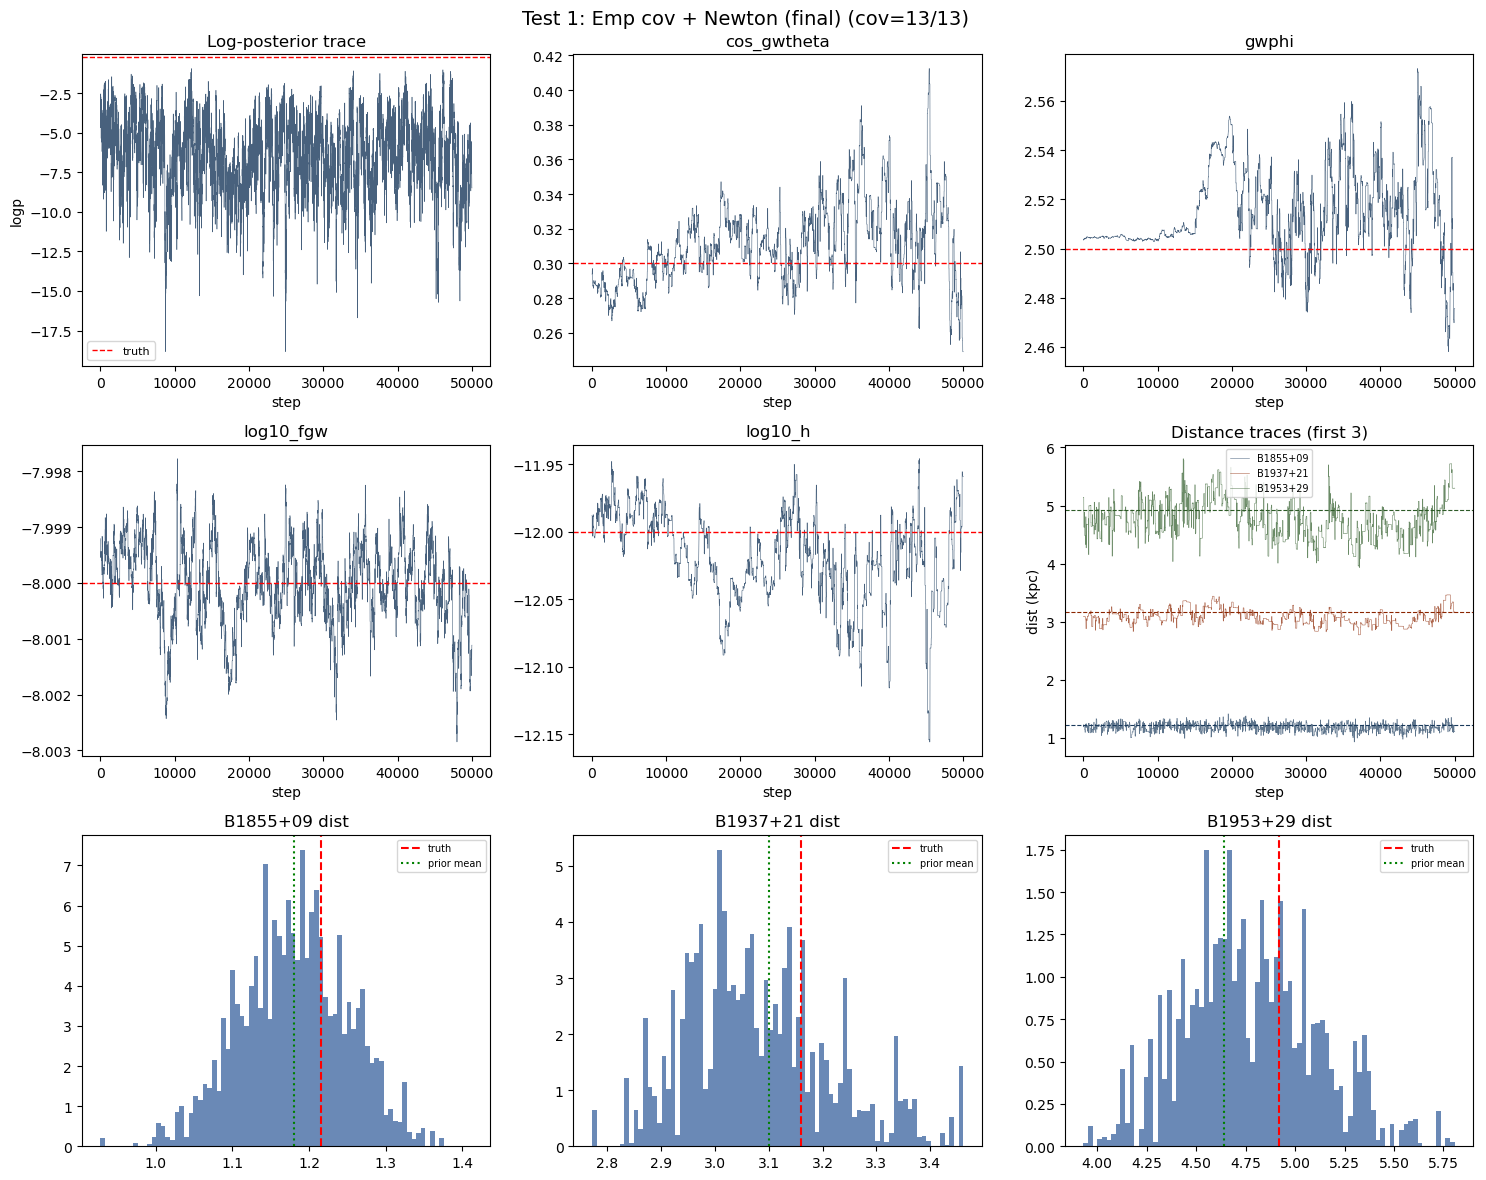

In [8]:
print("Test 1: Start from truth (empirical cov + Newton snap, FINAL)")
print(f"  logp(truth) = {lp_truth:.2f}")

dL_start = np.array(compute_delta_L(p5_truth[0], p5_truth[1], p5_truth[4]))

chain1, lps1, ar1 = run_sampler(
    logp, p5_truth.copy(), np.random.default_rng(42),
    fisher_dict=fisher, dL_arr=dL_start, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=5000, n_prod=50000, report_every=10000,
    adapt_prod_steps=0)  # no production adaptation — empirical cov is sufficient

cov1, ess1 = run_diagnostics(chain1, lps1, ar1, p5_truth, dL_start,
                              title='Test 1: Emp cov + Newton (final)')

## Test 2: Harder convergence test — shifted CW params AND distances

Starting with CW params offset from truth AND distances shifted to wrong modes.
Tests whether the sampler can recover from a realistic "cold start" scenario.

Test 2a: MODERATE CW offsets (~2-3x posterior std):
  cos_gwtheta    : 0.3000 -> 0.3200 (delta=+0.0200)
  gwphi          : 2.5000 -> 2.5030 (delta=+0.0030)
  cos_inc        : -0.2000 -> -0.1200 (delta=+0.0800)
  log10_mc       : 9.0000 -> 9.0200 (delta=+0.0200)
  log10_fgw      : -8.0000 -> -7.9980 (delta=+0.0020)
  log10_h        : -12.0000 -> -11.9600 (delta=+0.0400)
  phase0         : 1.0000 -> 1.1500 (delta=+0.1500)
  psi            : 0.7000 -> 0.7400 (delta=+0.0400)

Shifting distances (within 2-sigma)...



  logp = -136.56  (truth = -0.23)
  B1855+09: err = 31 dL from truth
  B1937+21: err = 664 dL from truth
  B1953+29: err = 2912 dL from truth
  J0023+0923: err = 269 dL from truth
  J0030+0451: err = 7 dL from truth
  Computing Hessian...


  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [-9.27654067e+01  1.86352150e+03  1.41713112e+04  7.01756875e+04
  4.19818206e+08  1.19024578e+10  2.98465218e+10  1.18843549e+13]
  Eigenmode proposal widths: [6.90381297e-07 1.37762230e-05 2.18151711e-05 1.16157250e-04
 8.98428704e-03 1.99927226e-02 5.51327624e-02 6.90381508e-01]
  Eigenvalue range: -1.3e+11
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000581, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000585, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000606, ratio=0.006
  Pulsar 3: Fisher sig_d=0.000004, dL=0.000590, ratio=0.007
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000586, ratio=0.004


  [Switching to empirical CW covariance at burn-in step 4000]
  Empirical CW std vs Fisher eigenmode widths:
    cos_gwtheta    : emp_std=3.41e-04, eig_sig=6.90e-07
    gwphi          : emp_std=2.52e-04, eig_sig=1.38e-05
    cos_inc        : emp_std=3.61e-02, eig_sig=2.18e-05
    log10_mc       : emp_std=1.16e-03, eig_sig=1.16e-04
    log10_fgw      : emp_std=3.55e-04, eig_sig=8.98e-03
    log10_h        : emp_std=1.23e-02, eig_sig=2.00e-02
    phase0         : emp_std=7.22e-02, eig_sig=5.51e-02
    psi            : emp_std=1.38e-02, eig_sig=6.90e-01
  New eigenmode widths: [0.00019327 0.00041261 0.00075074 0.0017697  0.01106429 0.02543642
 0.03586386 0.19177769]
  Computing Hessian...


  Hessian computed in 0.3s

  CW Fisher eigenvalues (precision): [6.96374820e+02 1.16192735e+03 1.68519769e+04 6.57059729e+04
 1.65264741e+07 1.93347921e+10 3.03184128e+10 1.32055919e+13]
  Eigenmode proposal widths: [6.54934773e-07 1.36685903e-05 1.71161942e-05 5.85446013e-04
 9.28484230e-03 1.83337595e-02 6.98212260e-02 9.01893854e-02]
  Eigenvalue range: 1.9e+10
  Pulsar 0: Fisher sig_d=0.000004, dL=0.000580, ratio=0.006
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000584, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000004, dL=0.000606, ratio=0.007
  Pulsar 3: Fisher sig_d=0.000005, dL=0.000590, ratio=0.008
  Pulsar 4: Fisher sig_d=0.000003, dL=0.000586, ratio=0.005


...

  [prod 30000/58000] lp=-10.54 EIG=0.283 JT=0.001 BJ=0.372 FD=0.377 [412 it/s, ETA 68s]


  [prod 40000/58000] lp=-5.29 EIG=0.253 JT=0.001 BJ=0.371 FD=0.386 [409 it/s, ETA 44s]


  [prod 50000/58000] lp=-2.61 EIG=0.229 JT=0.001 BJ=0.374 FD=0.388 [406 it/s, ETA 20s]



Done in 143.3s (405 it/s)
  cw_eigen       :   4315/ 20210 = 0.2135
  dist_within    :   4099/  5798 = 0.7070
  big_jump       :   6608/ 17498 = 0.3776
  freq_dist      :   2281/  5847 = 0.3901
  cw_joint       :      5/  8647 = 0.0006

  Per-eigenmode AR (adapted scale factors):
    mode 0 (sig=4.31e-04, scale=0.938, eff_sig=4.04e-04): 630/2526 = 0.2494
    mode 1 (sig=5.75e-03, scale=0.828, eff_sig=4.76e-03): 697/2571 = 0.2711
    mode 2 (sig=9.30e-03, scale=0.951, eff_sig=8.84e-03): 667/2524 = 0.2643
    mode 3 (sig=1.66e-02, scale=1.071, eff_sig=1.78e-02): 594/2573 = 0.2309
    mode 4 (sig=4.32e-02, scale=0.940, eff_sig=4.06e-02): 510/2508 = 0.2033
    mode 5 (sig=6.05e-02, scale=0.883, eff_sig=5.35e-02): 475/2483 = 0.1913
    mode 6 (sig=1.01e-01, scale=0.772, eff_sig=7.83e-02): 443/2495 = 0.1776
    mode 7 (sig=2.26e-01, scale=0.751, eff_sig=1.70e-01): 299/2530 = 0.1182
Coverage: 13/13


ESS range: [58, 1017]
  cos_gwtheta         : ESS=62
  gwphi               : ESS=63
  cos_inc             : ESS=74
  log10_mc            : ESS=62
  log10_fgw           : ESS=63
  log10_h             : ESS=68
  phase0              : ESS=58
  psi                 : ESS=81
  B1855+09_dist       : ESS=225
  B1937+21_dist       : ESS=68
  B1953+29_dist       : ESS=104
  J0023+0923_dist     : ESS=1017
  J0030+0451_dist     : ESS=899

Distance errors:
  B1855+09     : median=1.167366, truth=1.216000, err=83.9 dL
  B1937+21     : median=3.068879, truth=3.160000, err=156.4 dL
  B1953+29     : median=4.696017, truth=4.919000, err=369.8 dL
  J0023+0923   : median=1.014283, truth=1.053000, err=65.5 dL
  J0030+0451   : median=0.329397, truth=0.330680, err=2.2 dL

Acceptance rates:
  cw_eigen       : 0.2135
  dist_within    : 0.7070
  big_jump       : 0.3776
  freq_dist      : 0.3901
  cw_joint       : 0.0006


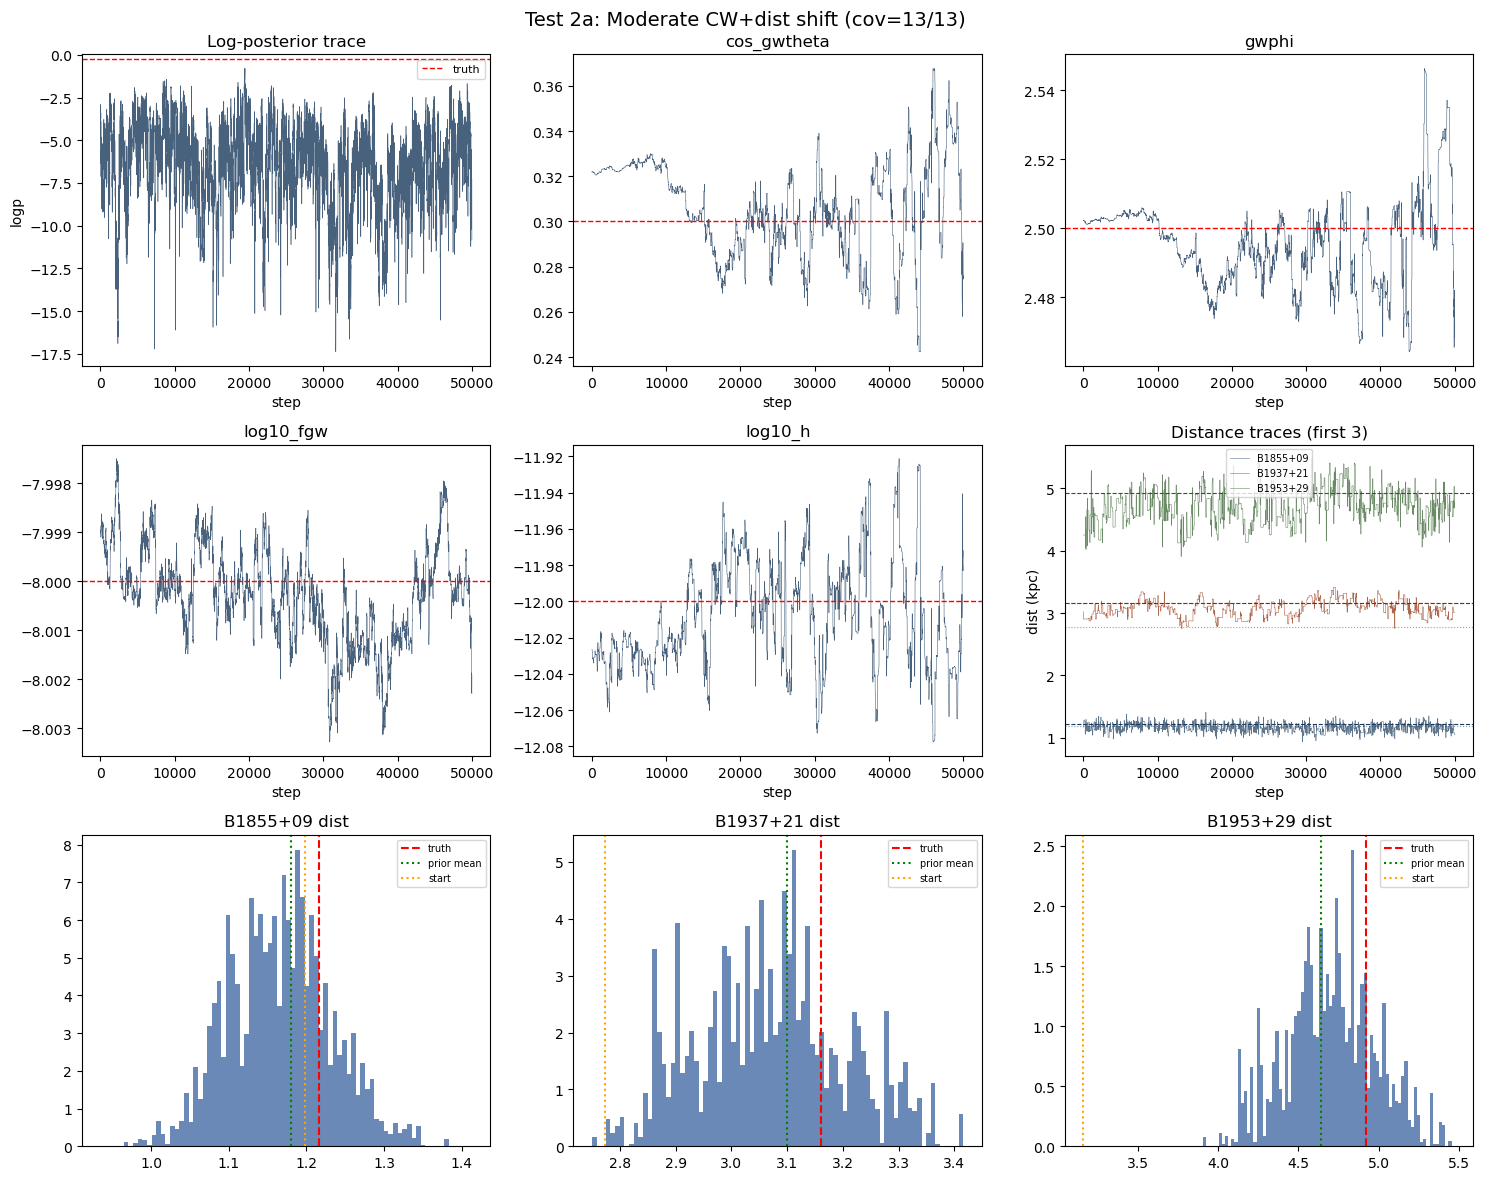



Test 2b: LARGE CW offsets (~5-100x posterior std):
  cos_gwtheta    : 0.3000 -> 0.3500 (delta=+0.0500)
  gwphi          : 2.5000 -> 2.6500 (delta=+0.1500)
  cos_inc        : -0.2000 -> -0.1000 (delta=+0.1000)
  log10_mc       : 9.0000 -> 9.0500 (delta=+0.0500)
  log10_fgw      : -8.0000 -> -7.9900 (delta=+0.0100)
  log10_h        : -12.0000 -> -11.7000 (delta=+0.3000)
  phase0         : 1.0000 -> 1.5000 (delta=+0.5000)
  psi            : 0.7000 -> 0.9000 (delta=+0.2000)

Shifting distances (within 3-sigma)...

  logp = -8699.51  (truth = -0.23)
  B1855+09: err = 245 dL from truth
  B1937+21: err = 165 dL from truth
  B1953+29: err = 777 dL from truth
  J0023+0923: err = 114 dL from truth
  J0030+0451: err = 19 dL from truth
  Computing Hessian...


  Hessian computed in 0.4s

  CW Fisher eigenvalues (precision): [-7.63559913e+04  7.25512904e+03  5.42474896e+04  2.95974589e+05
  9.63652624e+07  9.19738604e+10  1.69294001e+11  6.31531004e+13]
  Eigenmode proposal widths: [2.99488528e-07 5.78437120e-06 7.84774247e-06 2.42446938e-04
 4.37471479e-03 1.02184996e-02 2.79418004e-02 2.99488133e-01]
  Eigenvalue range: -8.3e+08
  Pulsar 0: Fisher sig_d=0.000002, dL=0.000609, ratio=0.003
  Pulsar 1: Fisher sig_d=0.000001, dL=0.000607, ratio=0.002
  Pulsar 2: Fisher sig_d=0.000002, dL=0.000627, ratio=0.003
  Pulsar 3: Fisher sig_d=0.000002, dL=0.000555, ratio=0.004
  Pulsar 4: Fisher sig_d=0.000001, dL=0.000550, ratio=0.002


  [Switching to empirical CW covariance at burn-in step 4000]
  Empirical CW std vs Fisher eigenmode widths:
    cos_gwtheta    : emp_std=2.59e-04, eig_sig=2.99e-07
    gwphi          : emp_std=4.86e-05, eig_sig=5.78e-06
    cos_inc        : emp_std=6.06e-02, eig_sig=7.85e-06
    log10_mc       : emp_std=2.74e-04, eig_sig=2.42e-04
    log10_fgw      : emp_std=3.41e-05, eig_sig=4.37e-03
    log10_h        : emp_std=7.05e-02, eig_sig=1.02e-02
    phase0         : emp_std=1.09e-01, eig_sig=2.79e-02
    psi            : emp_std=6.61e-02, eig_sig=2.99e-01
  New eigenmode widths: [1.52066228e-05 3.91698243e-05 4.73759114e-05 2.72817208e-04
 1.91450064e-02 6.64852857e-02 1.61931655e-01 3.32525291e-01]
  Computing Hessian...


  Hessian computed in 0.2s

  CW Fisher eigenvalues (precision): [3.48206299e+02 8.01686240e+03 3.14372210e+04 1.01567560e+05
 1.70935577e+08 1.60870449e+10 4.62138639e+10 1.28993982e+13]
  Eigenmode proposal widths: [6.62662409e-07 1.10711011e-05 1.87645788e-05 1.82037443e-04
 7.46791641e-03 1.34231636e-02 2.65812097e-02 1.27543592e-01]
  Eigenvalue range: 3.7e+10
  Pulsar 0: Fisher sig_d=0.000003, dL=0.000609, ratio=0.005
  Pulsar 1: Fisher sig_d=0.000002, dL=0.000607, ratio=0.004
  Pulsar 2: Fisher sig_d=0.000006, dL=0.000627, ratio=0.009
  Pulsar 3: Fisher sig_d=0.000006, dL=0.000556, ratio=0.010
  Pulsar 4: Fisher sig_d=0.000006, dL=0.000550, ratio=0.010


  [prod 10000/58000] lp=-42.68 EIG=0.372 JT=0.012 BJ=0.391 FD=0.221 [393 it/s, ETA 122s]


...

  [prod 30000/58000] lp=-40.61 EIG=0.257 JT=0.004 BJ=0.401 FD=0.292 [407 it/s, ETA 69s]


  [prod 40000/58000] lp=-41.71 EIG=0.242 JT=0.003 BJ=0.405 FD=0.309 [406 it/s, ETA 44s]


  [prod 50000/58000] lp=-40.07 EIG=0.232 JT=0.002 BJ=0.406 FD=0.318 [404 it/s, ETA 20s]



Done in 143.5s (404 it/s)
  cw_eigen       :   4660/ 20210 = 0.2306
  dist_within    :   4134/  5798 = 0.7130
  big_jump       :   7127/ 17498 = 0.4073
  freq_dist      :   1889/  5847 = 0.3231
  cw_joint       :     18/  8647 = 0.0021

  Per-eigenmode AR (adapted scale factors):
    mode 0 (sig=1.53e-05, scale=1.284, eff_sig=1.97e-05): 1697/2526 = 0.6718
    mode 1 (sig=6.11e-05, scale=2.848, eff_sig=1.74e-04): 702/2571 = 0.2730
    mode 2 (sig=1.22e-04, scale=2.767, eff_sig=3.37e-04): 622/2524 = 0.2464
    mode 3 (sig=1.75e-04, scale=2.950, eff_sig=5.18e-04): 372/2573 = 0.1446
    mode 4 (sig=2.73e-04, scale=1.096, eff_sig=2.99e-04): 521/2508 = 0.2077
    mode 5 (sig=4.85e-04, scale=0.823, eff_sig=3.99e-04): 240/2483 = 0.0967
    mode 6 (sig=6.03e-04, scale=0.740, eff_sig=4.47e-04): 291/2495 = 0.1166
    mode 7 (sig=1.02e-03, scale=0.720, eff_sig=7.32e-04): 215/2530 = 0.0850
Coverage: 4/13


ESS range: [50, 1219]
  cos_gwtheta         : ESS=55
  gwphi               : ESS=50
  cos_inc             : ESS=54
  log10_mc            : ESS=53
  log10_fgw           : ESS=78
  log10_h             : ESS=72
  phase0              : ESS=56
  psi                 : ESS=76
  B1855+09_dist       : ESS=667
  B1937+21_dist       : ESS=130
  B1953+29_dist       : ESS=374
  J0023+0923_dist     : ESS=952
  J0030+0451_dist     : ESS=1219

Distance errors:
  B1855+09     : median=1.205970, truth=1.216000, err=17.3 dL
  B1937+21     : median=2.882463, truth=3.160000, err=476.4 dL
  B1953+29     : median=4.785640, truth=4.919000, err=221.2 dL
  J0023+0923   : median=0.981641, truth=1.053000, err=120.8 dL
  J0030+0451   : median=0.329536, truth=0.330680, err=1.9 dL

Acceptance rates:
  cw_eigen       : 0.2306
  dist_within    : 0.7130
  big_jump       : 0.4073
  freq_dist      : 0.3231
  cw_joint       : 0.0021


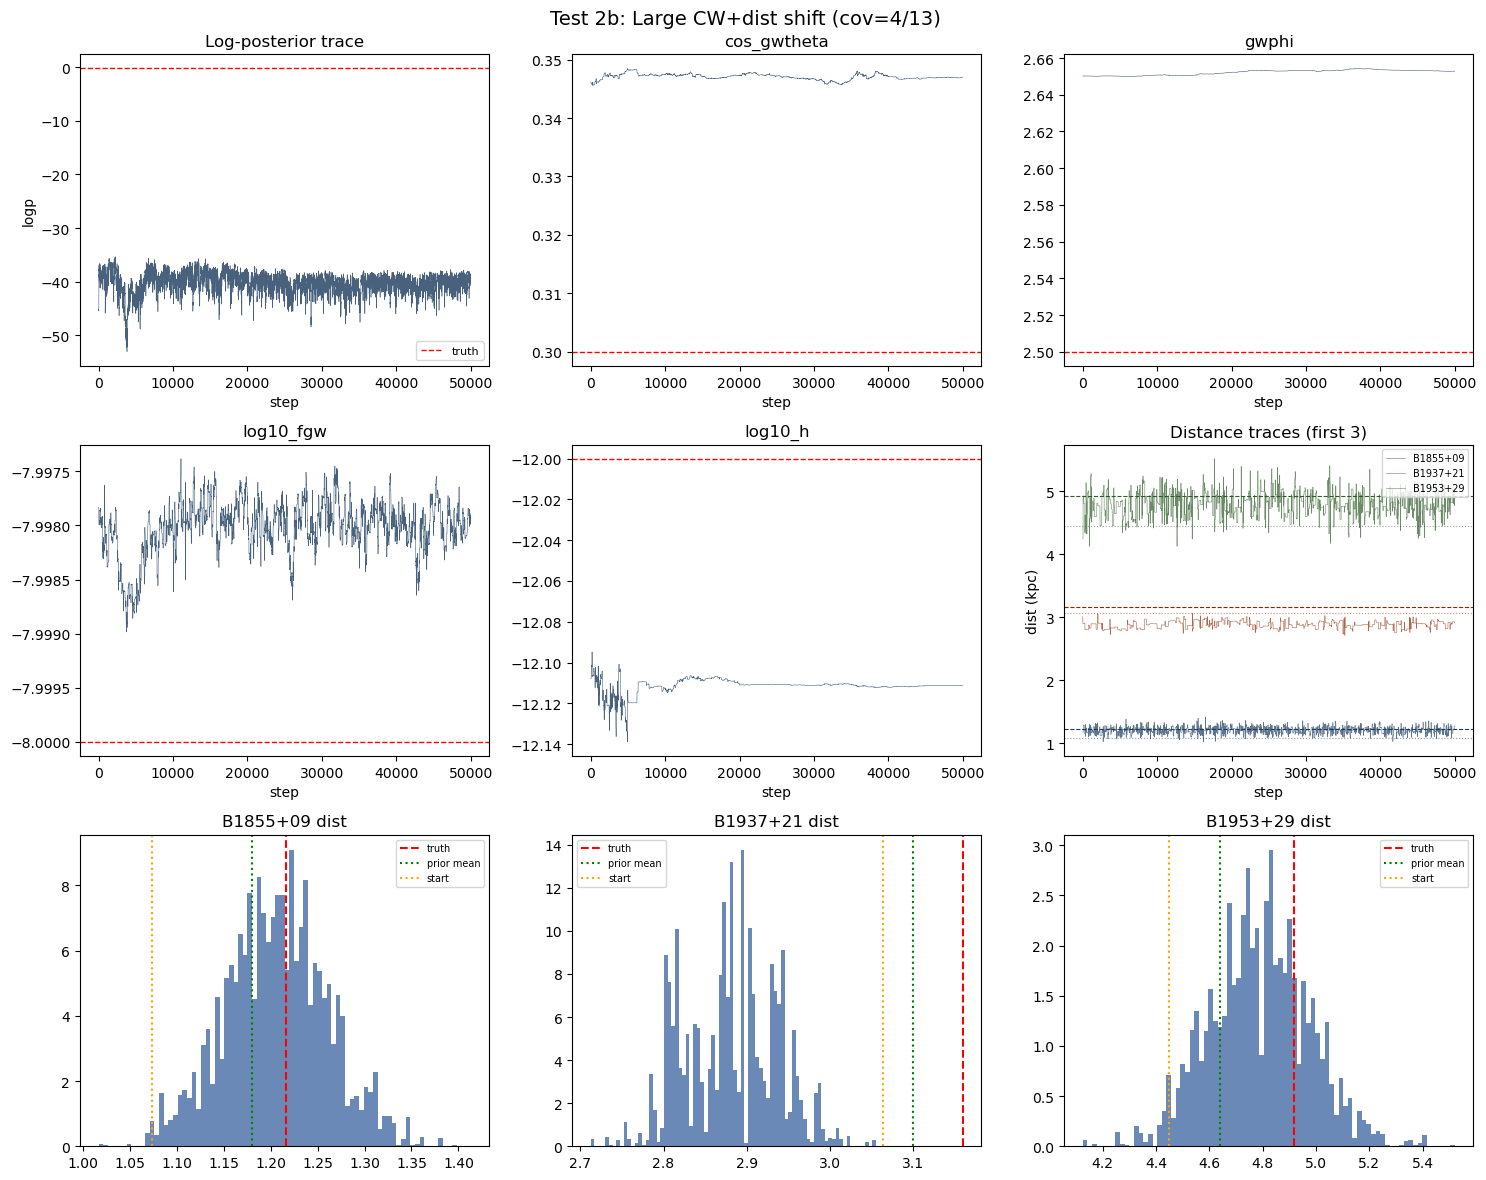

In [9]:
# ====== Test 2a: MODERATE offsets (CW within ~2-3 posterior std) ======
rng_shift = np.random.default_rng(789)

x_mod = p5_truth.copy()

# CW offsets ~2-3x posterior std (std from chain: cos_gwtheta~0.009, gwphi~0.001, etc.)
cw_offsets_mod = {
    'cos_gwtheta': 0.02,   # ~2x chain std
    'gwphi':       0.003,  # ~2x chain std
    'cos_inc':     0.08,   # ~2x chain std
    'log10_mc':    0.02,   # ~2x chain std
    'log10_fgw':   0.002,  # ~3x chain std
    'log10_h':     0.04,   # ~2.5x chain std
    'phase0':      0.15,   # ~2.5x chain std
    'psi':         0.04,   # ~2.5x chain std
}
print("Test 2a: MODERATE CW offsets (~2-3x posterior std):")
for i, (name, offset) in enumerate(cw_offsets_mod.items()):
    x_mod[i] = p5_truth[i] + offset
    print(f"  {name:15s}: {p5_truth[i]:.4f} -> {x_mod[i]:.4f} (delta={offset:+.4f})")

# Distance shifts within 2-sigma
print("\nShifting distances (within 2-sigma)...")
for j in range(Npulsars):
    mu_j = float(dist_mu[j])
    sig_j = float(dist_sig[j])
    dL_j = dL_truth[j]
    max_modes_up = int((mu_j + 2*sig_j - p5_truth[8+j]) / dL_j)
    max_modes_dn = int((p5_truth[8+j] - max(mu_j - 2*sig_j, dL_j)) / dL_j)
    n_shift = rng_shift.integers(min(-max_modes_dn, -3), max(max_modes_up, 3)+1)
    if abs(n_shift) < 3:
        n_shift = rng_shift.choice([-5, 5])
    x_mod[8+j] += n_shift * dL_j
    x_mod[8+j] = np.clip(x_mod[8+j], dL_j, mu_j + 2*sig_j)

dL_mod = np.array(compute_delta_L(x_mod[0], x_mod[1], x_mod[4]))
for j in range(Npulsars):
    x_mod[8+j] = snap_to_peak(x_mod, j, float(dL_mod[j]), n_pts=200)

lp_mod = float(logp(jnp.array(x_mod)))
print(f"\n  logp = {lp_mod:.2f}  (truth = {lp_truth:.2f})")
for j in range(Npulsars):
    err_dL = abs(x_mod[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name}: err = {err_dL:.0f} dL from truth")

fisher_mod = compute_fisher(x_mod, logp)

chain2a, lps2a, ar2a = run_sampler(
    logp, x_mod.copy(), np.random.default_rng(42),
    fisher_dict=fisher_mod, dL_arr=dL_mod, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=10000,
    adapt_prod_steps=0)

cov2a, ess2a = run_diagnostics(chain2a, lps2a, ar2a, p5_truth, dL_truth,
                              title='Test 2a: Moderate CW+dist shift',
                              show_start=x_mod)

# ====== Test 2b: LARGE offsets (CW ~5x posterior std) ======
rng_shift2 = np.random.default_rng(456)

x_hard = p5_truth.copy()

cw_offsets_hard = {
    'cos_gwtheta': 0.05,   # ~5x chain std
    'gwphi':       0.15,   # ~100x chain std (way off)
    'cos_inc':     0.1,    # ~2.5x chain std
    'log10_mc':    0.05,   # ~5x chain std
    'log10_fgw':   0.01,   # ~14x chain std
    'log10_h':     0.3,    # ~18x chain std
    'phase0':      0.5,    # ~8x chain std
    'psi':         0.2,    # ~12x chain std
}
print("\n\nTest 2b: LARGE CW offsets (~5-100x posterior std):")
for i, (name, offset) in enumerate(cw_offsets_hard.items()):
    x_hard[i] = p5_truth[i] + offset
    print(f"  {name:15s}: {p5_truth[i]:.4f} -> {x_hard[i]:.4f} (delta={offset:+.4f})")

# Distance shifts within 3-sigma
print("\nShifting distances (within 3-sigma)...")
for j in range(Npulsars):
    mu_j = float(dist_mu[j])
    sig_j = float(dist_sig[j])
    dL_j = dL_truth[j]
    max_modes_up = int((mu_j + 3*sig_j - p5_truth[8+j]) / dL_j)
    max_modes_dn = int((p5_truth[8+j] - max(mu_j - 3*sig_j, dL_j)) / dL_j)
    n_shift = rng_shift2.integers(min(-max_modes_dn, -5), max(max_modes_up, 5)+1)
    if abs(n_shift) < 3:
        n_shift = rng_shift2.choice([-5, 5]) * rng_shift2.integers(1, 4)
    x_hard[8+j] += n_shift * dL_j
    x_hard[8+j] = np.clip(x_hard[8+j], dL_j, mu_j + 3*sig_j)

dL_hard = np.array(compute_delta_L(x_hard[0], x_hard[1], x_hard[4]))
for j in range(Npulsars):
    x_hard[8+j] = snap_to_peak(x_hard, j, float(dL_hard[j]), n_pts=200)

lp_hard = float(logp(jnp.array(x_hard)))
print(f"\n  logp = {lp_hard:.2f}  (truth = {lp_truth:.2f})")
for j in range(Npulsars):
    err_dL = abs(x_hard[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name}: err = {err_dL:.0f} dL from truth")

fisher_hard = compute_fisher(x_hard, logp)

chain2b, lps2b, ar2b = run_sampler(
    logp, x_hard.copy(), np.random.default_rng(42),
    fisher_dict=fisher_hard, dL_arr=dL_hard, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=10000,
    adapt_prod_steps=0)

cov2b, ess2b = run_diagnostics(chain2b, lps2b, ar2b, p5_truth, dL_truth,
                              title='Test 2b: Large CW+dist shift',
                              show_start=x_hard)


## Test 3: Grid-search initialization + annealing — Large CW offsets

Same hard starting point as Test 2b, but using a proper two-step initialization:
1. **Step 1**: Coarse grid search — draw 8000 random CW param sets from the prior,
   batch-evaluate logp with `jax.vmap`, then run scipy L-BFGS-B (exact JAX gradients)
   from the top-30 candidates.  Zero speed overhead after the MCMC starts.
2. **Step 2**: Run `run_sampler_anneal` from the grid MAP, with T_start=30 cooling
   to T=1 during burn-in to correct any residual basin error.

No parallel chains — same single-chain speed (~400 it/s) as Test 1.


Test 3: Grid-search + annealing — Large CW offsets

Starting from Test 2b initial point  (logp=-8699.51)
Truth logp = -0.23

--- Step 1: Grid search + L-BFGS-B ---
  Stage 1: Earth-term-only grid eval (25×50×80×5 = 500000)


    first chunk compiled in 14.9s


    done in 15.4s, 495000/500000 valid, best grid logp = -2460.7

  Stage 2: Earth-term L-BFGS-B from top 50 grids


    done in 10.2s, best Earth-term logp = -730.38
    E-opt 0: logp_earth=-730.38, cos_gwtheta=0.7885, gwphi=4.4807, log10_fgw=-8.02154
    E-opt 1: logp_earth=-730.38, cos_gwtheta=0.7885, gwphi=4.4807, log10_fgw=-8.02154
    E-opt 2: logp_earth=-730.38, cos_gwtheta=0.7885, gwphi=4.4807, log10_fgw=-8.02154
    E-opt 3: logp_earth=-730.38, cos_gwtheta=0.7885, gwphi=4.4807, log10_fgw=-8.02154
    E-opt 4: logp_earth=-730.38, cos_gwtheta=0.7885, gwphi=4.4807, log10_fgw=-8.02154

  Stage 3: distance-snap 20 distinct sky modes


    done in 169.0s, best after snap = -1637.19
    snap 0: full_logp=-1637.19, cos_gwtheta=-1.0000, gwphi=3.1416
    snap 1: full_logp=-1637.19, cos_gwtheta=-1.0000, gwphi=0.0000
    snap 2: full_logp=-1807.81, cos_gwtheta=1.0000, gwphi=5.0001
    snap 3: full_logp=-1850.77, cos_gwtheta=0.4033, gwphi=5.1436
    snap 4: full_logp=-1977.33, cos_gwtheta=0.6653, gwphi=2.7242

  Stage 4: full L-BFGS-B from top 10 snapped


...

  [prod 30000/58000] lp=-181.96 EIG=0.359 JT=0.002 BJ=0.346 FD=0.591 [399 it/s, ETA 70s]


  [prod 40000/58000] lp=-180.27 EIG=0.296 JT=0.001 BJ=0.347 FD=0.605 [400 it/s, ETA 45s]


  [prod 50000/58000] lp=-178.76 EIG=0.264 JT=0.001 BJ=0.347 FD=0.606 [399 it/s, ETA 20s]



Done in 145.1s (400 it/s)
  cw_eigen       :   4962/ 20210 = 0.2455
  dist_within    :   4285/  5798 = 0.7390
  big_jump       :   6034/ 17498 = 0.3448
  freq_dist      :   3563/  5847 = 0.6094
  cw_joint       :      7/  8647 = 0.0008

  Per-eigenmode AR (adapted scale factors):
    mode 0 (sig=3.56e-04, scale=16.639, eff_sig=5.93e-03): 858/2526 = 0.3397
    mode 1 (sig=6.05e-04, scale=17.176, eff_sig=1.04e-02): 749/2571 = 0.2913
    mode 2 (sig=7.58e-04, scale=7.755, eff_sig=5.88e-03): 454/2524 = 0.1799
    mode 3 (sig=1.78e-03, scale=1.688, eff_sig=3.00e-03): 613/2573 = 0.2382
    mode 4 (sig=4.00e-03, scale=0.946, eff_sig=3.78e-03): 736/2508 = 0.2935
    mode 5 (sig=1.01e-02, scale=0.957, eff_sig=9.66e-03): 591/2483 = 0.2380
    mode 6 (sig=1.71e-02, scale=0.863, eff_sig=1.48e-02): 541/2495 = 0.2168
    mode 7 (sig=1.96e-02, scale=0.933, eff_sig=1.83e-02): 420/2530 = 0.1660
Coverage: 2/13


ESS range: [51, 953]
  cos_gwtheta         : ESS=52
  gwphi               : ESS=53
  cos_inc             : ESS=53
  log10_mc            : ESS=51
  log10_fgw           : ESS=60
  log10_h             : ESS=68
  phase0              : ESS=52
  psi                 : ESS=68
  B1855+09_dist       : ESS=63
  B1937+21_dist       : ESS=52
  B1953+29_dist       : ESS=89
  J0023+0923_dist     : ESS=953
  J0030+0451_dist     : ESS=62

Distance errors:
  B1855+09     : median=0.803046, truth=1.216000, err=712.4 dL
  B1937+21     : median=3.419699, truth=3.160000, err=445.8 dL
  B1953+29     : median=5.733153, truth=4.919000, err=1350.3 dL
  J0023+0923   : median=1.033843, truth=1.053000, err=32.4 dL
  J0030+0451   : median=0.329002, truth=0.330680, err=2.9 dL

Acceptance rates:
  cw_eigen       : 0.2455
  dist_within    : 0.7390
  big_jump       : 0.3448
  freq_dist      : 0.6094
  cw_joint       : 0.0008


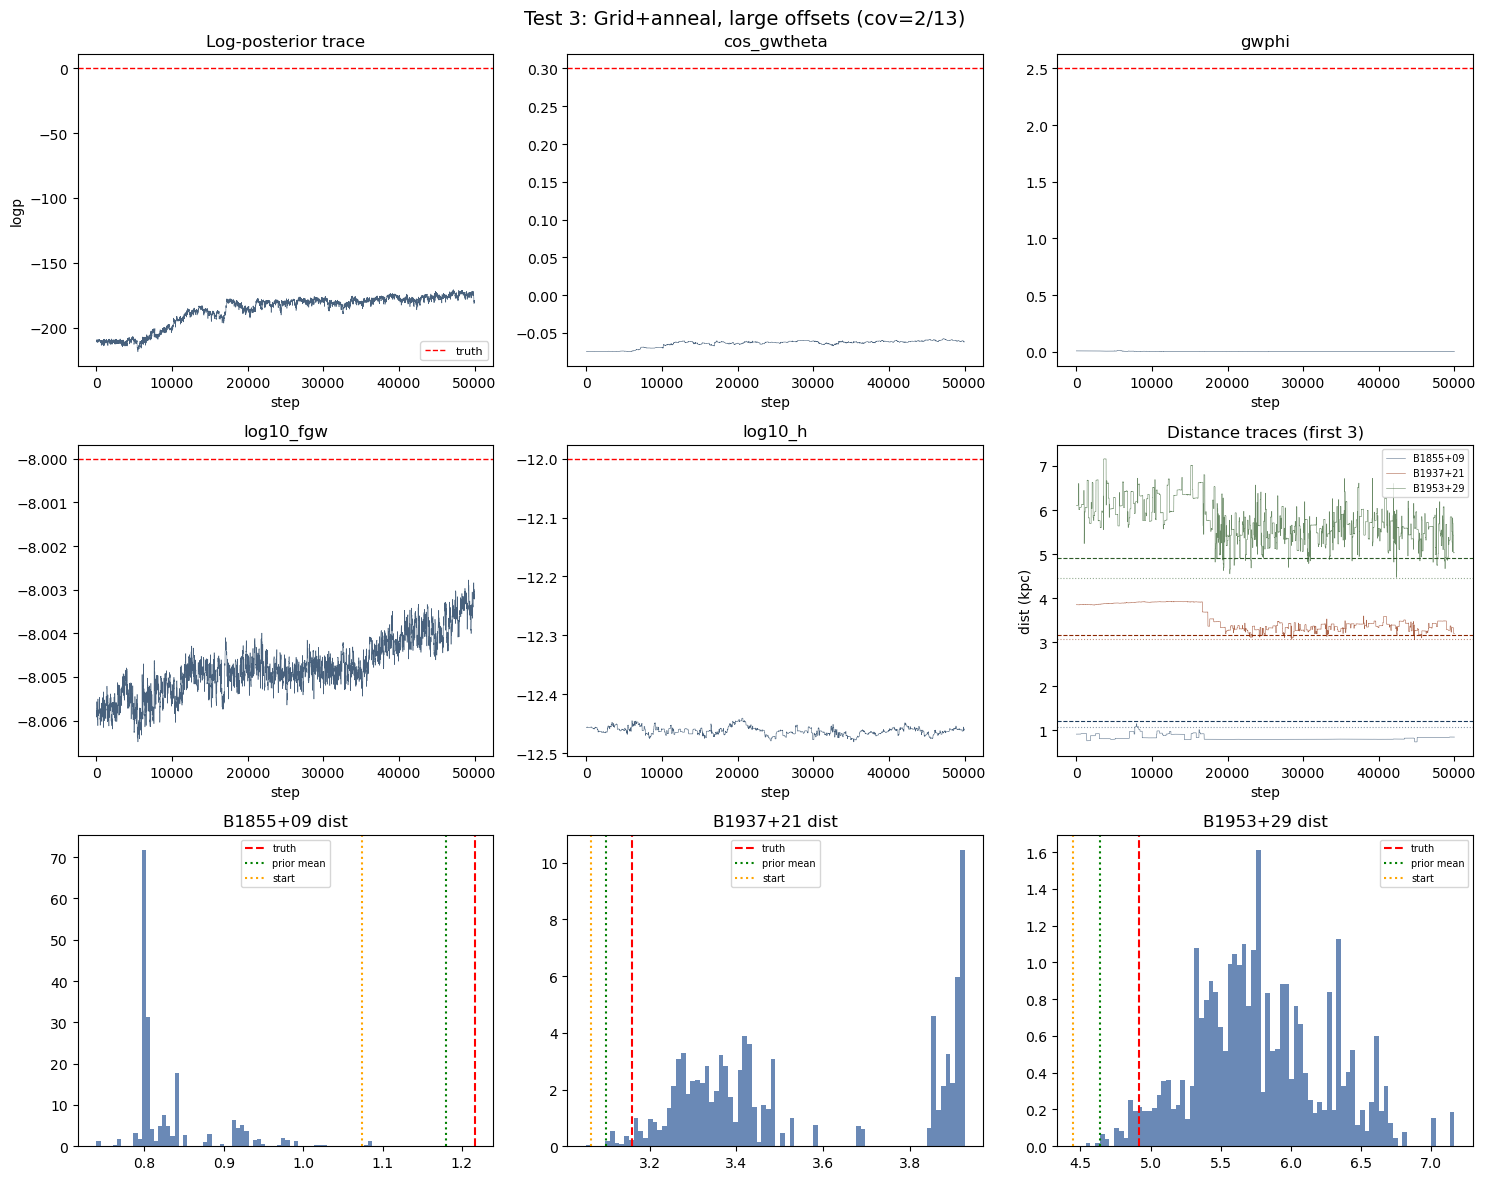

In [10]:

# Test 3: Grid-search initialization + annealing from large CW offsets
print("=" * 65)
print("Test 3: Grid-search + annealing — Large CW offsets")
print("=" * 65)
print(f"\nStarting from Test 2b initial point  (logp={lp_hard:.2f})")
print(f"Truth logp = {lp_truth:.2f}")

# --- Step 1: Coarse grid search + L-BFGS-B ---
print("\n--- Step 1: Grid search + L-BFGS-B ---")
t_grid_start = time.time()
x_grid, lp_grid = find_basin_grid(
    logp, grad_logp, mu_arr, sd_arr,
    logp_earth_fn=logp_earth, grad_logp_earth_fn=grad_logp_earth,
    n_top=50, max_opt_iter=300, seed=99)
t_grid = time.time() - t_grid_start
print(f"  Total time: {t_grid:.1f}s")

# Show MAP vs truth
print(f"\n  Grid MAP vs truth (logp={lp_grid:.3f}):")
cw_names_show = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc',
                 'log10_fgw', 'log10_h', 'phase0', 'psi']
for i, name in enumerate(cw_names_show):
    delta = x_grid[i] - p5_truth[i]
    nsig  = delta / np.std(chain1[:, i]) if np.std(chain1[:, i]) > 0 else float('inf')
    print(f"    {name:15s}: found={x_grid[i]:.5f}, truth={p5_truth[i]:.5f}, "
          f"delta={delta:+.4f} ({nsig:+.1f} post.sigma)")
dL_grid = np.array(compute_delta_L(x_grid[0], x_grid[1], x_grid[4]))
for j in range(Npulsars):
    err_dL = abs(x_grid[8+j] - p5_truth[8+j]) / dL_truth[j]
    print(f"    {disco_psrs[j].name:15s}: found={x_grid[8+j]:.5f}, "
          f"truth={p5_truth[8+j]:.5f},  err={err_dL:.1f} dL")

# Compute Fisher at grid MAP point
print(f"\n  Computing Fisher at grid MAP point:")
fisher_grid = compute_fisher(x_grid, logp)

# --- Step 2: Annealing sampler from grid MAP ---
print(f"\n--- Step 2: Annealing sampler (T_start=30, cool over 60% of burn-in) ---")
chain3, lps3, ar3 = run_sampler_anneal(
    logp, x_grid.copy(), np.random.default_rng(42),
    fisher_dict=fisher_grid, dL_arr=dL_grid, mu_arr=mu_arr, sig_arr=sd_arr,
    n_burn=8000, n_prod=50000, report_every=10000,
    T_start=30.0, T_anneal_frac=0.6,
    adapt_prod_steps=0)

cov3, ess3 = run_diagnostics(chain3, lps3, ar3, p5_truth, dL_truth,
                              title='Test 3: Grid+anneal, large offsets',
                              show_start=x_hard)


In [11]:
# Side-by-side comparison: truth vs moderate vs large offsets vs MAP+anneal
print(f"{'='*95}")
print(f"{'':20s} {'Test 1':>15s} {'Test 2a':>15s} {'Test 2b':>15s} {'Test 3':>15s}")
print(f"{'':20s} {'(truth)':>15s} {'(moderate)':>15s} {'(large)':>15s} {'(MAP+anneal)':>15s}")
print(f"{'='*95}")
print(f"{'Coverage':20s} {cov1:>10d}/13   {cov2a:>10d}/13   {cov2b:>10d}/13   {cov3:>10d}/13")
print(f"{'ESS min':20s} {min(ess1.values()):>13.0f}   {min(ess2a.values()):>13.0f}   {min(ess2b.values()):>13.0f}   {min(ess3.values()):>13.0f}")
print(f"{'CW Eigen AR':20s} {ar1['cw_eigen']:>13.4f}   {ar2a['cw_eigen']:>13.4f}   {ar2b['cw_eigen']:>13.4f}   {ar3['cw_eigen']:>13.4f}")
print(f"{'Big jump AR':20s} {ar1['big_jump']:>13.4f}   {ar2a['big_jump']:>13.4f}   {ar2b['big_jump']:>13.4f}   {ar3['big_jump']:>13.4f}")
print(f"{'='*95}")

cw_keys = ['cos_gwtheta', 'gwphi', 'cos_inc', 'log10_mc', 'log10_fgw',
           'log10_h', 'phase0', 'psi']
print(f"\nCW parameter ESS:")
print(f"  {'Param':20s} {'Test 1':>10s} {'Test 2a':>10s} {'Test 2b':>10s} {'Test 3':>10s}")
for k in cw_keys:
    print(f"  {k:20s} {ess1[k]:>10.0f} {ess2a[k]:>10.0f} {ess2b[k]:>10.0f} {ess3[k]:>10.0f}")

print(f"\nPer-pulsar distance errors (dL from truth):")
print(f"  {'Pulsar':13s} {'Test 1':>10s} {'Test 2a':>10s} {'Test 2b':>10s} {'Test 3':>10s}")
for j in range(Npulsars):
    med1 = np.median(chain1[:, 8+j])
    med2a = np.median(chain2a[:, 8+j])
    med2b = np.median(chain2b[:, 8+j])
    med3 = np.median(chain3[:, 8+j])
    err1 = abs(med1 - p5_truth[8+j]) / dL_truth[j]
    err2a = abs(med2a - p5_truth[8+j]) / dL_truth[j]
    err2b = abs(med2b - p5_truth[8+j]) / dL_truth[j]
    err3 = abs(med3 - p5_truth[8+j]) / dL_truth[j]
    print(f"  {disco_psrs[j].name:13s} {err1:>10.1f} {err2a:>10.1f} {err2b:>10.1f} {err3:>10.1f}")

                              Test 1         Test 2a         Test 2b          Test 3
                             (truth)      (moderate)         (large)    (MAP+anneal)
Coverage                     13/13           13/13            4/13            2/13
ESS min                         62              58              50              51
CW Eigen AR                 0.2039          0.2135          0.2306          0.2455
Big jump AR                 0.3815          0.3776          0.4073          0.3448

CW parameter ESS:
  Param                    Test 1    Test 2a    Test 2b     Test 3
  cos_gwtheta                  73         62         55         52
  gwphi                        69         63         50         53
  cos_inc                      75         74         54         53
  log10_mc                     62         62         53         51
  log10_fgw                    81         63         78         60
  log10_h                      67         68         72         68
  phase0  